# Weight Optimization — Constrained Grid Search
### TI / SI / LI Pricing Weights to Maximise Revenue-Per-Hour

---

## What This Notebook Does

Our pricing model scores every flight corridor/time window using three signals:

| Signal | Name | What it measures |
|--------|------|------------------|
| **TI** | Time Index | How time-sensitive the route is (peak vs off-peak demand) |
| **SI** | Seasonality Index | How seasonal the route is (holiday peaks, summer rush) |
| **LI** | Loyalty Index | How loyal the customer base is on the route |

The composite score formula:

$$\text{Score} = w_{TI} \times TI + w_{SI} \times SI + w_{LI} \times LI$$

where $w_{TI} + w_{SI} + w_{LI} = 1.0$ (weights always sum to 100%).

We test **231 weight combinations** at 5% steps and find the one that concentrates  
the highest Revenue-Per-Hour flights in the top-scored 10% of capacity.

---

## Analysis Units (5 Dimensions)

Every unique combination of the following defines one pricing unit:

| Dimension | Column | Example |
|-----------|--------|---------|
| Corridor | `corridor` | NYC → MIA |
| Day of Week | `DOW` | Monday |
| Time of Day | `TOD` | Morning |
| Cabin | `flightrequestedAircraftCabinName` | Light Jet |
| Month | `month` | July |

Each unit also carries a **Seasonal flag (Y/N)** — whether that unit is subject to seasonality.

---

## Revenue Formulas

| Formula | Description |
|---------|-------------|
| `flightcost × 0.8` | **Network Avg RPH numerator** — raw cost minus 20% fuel/surcharge |
| `(flightcost − Toggle Delta) × 0.8` | **Base revenue** — strips existing toggle AND fuel |
| `base_revenue + Toggle Delta` | **Final revenue** — adds the toggle back (= flightcost×0.8 + Toggle×0.2) |
| `sum(final_revenue) / sum(hours)` | **Unit RPH** — used to rank units and compute lift |

---

## Sections
- **Part 1** — Full Network (all cabins combined)
- **Part 2** — Light Jet only
- **Part 3** — Super Midsize only
- **Part 4** — Month-by-Month analysis


---
## Step 0 — Setup

| Constant | Value | Meaning |
|----------|-------|---------|
| `GRID_STEP` | 5% | Weight increment — 0%, 5%, 10% … 100% |
| `TOP_DECILE_HOURS_PCT` | 10% | Top-decile = buckets totalling 10% of network billed hours |
| `MIN_FLIGHTS` | 5 | Minimum flights per bucket (removes noisy small samples) |
| `SPEARMAN_THRESHOLD` | 0.40 | Minimum Spearman r to be considered a stable combo |
| `BASELINE_W` | (0.6, 0.3, 0.1) | Current assumed weights TI / SI / LI |


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','--quiet',
                        'matplotlib','seaborn','mpltern','openpyxl','scipy'])

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

DATA_PATH            = 'Seasonal_Intensity_4.xlsx'
RESULTS_PATH         = 'optimization_results.csv'
GRID_STEP            = 0.05
TOP_DECILE_HOURS_PCT = 0.10
MIN_FLIGHTS          = 5
SPEARMAN_THRESHOLD   = 0.40
BASELINE_W           = (0.6, 0.3, 0.1)
GROUP_COLS           = ['corridor','DOW','TOD','flightrequestedAircraftCabinName','month']
CABIN_COL            = 'flightrequestedAircraftCabinName'

print('Setup complete.')


Setup complete.


---
## Step 1 — Load Data & Compute Revenue Fields

### Revenue Formulas

$$\text{Network Avg RPH} = \frac{\sum (\text{flightcost} \times 0.8)}{\sum \text{hours}}$$

$$\text{Base Revenue} = (\text{flightcost} - \text{Toggle Delta}) \times 0.8$$

$$\text{Final Revenue} = \text{Base Revenue} + \text{Toggle Delta}$$

> **Why two revenue fields?**  
> Base revenue strips both the toggle and fuel surcharge — it's the underlying market value.  
> Final revenue adds the toggle back, representing what we actually collect after the pricing toggle.  
> Unit RPH uses **final revenue** so we capture the real yield of each corridor/time window.

### Hours
Use `flightActualBilledHours` (no fallback needed — no nulls confirmed in data).

### SI Null Handling
`SI_Toggle` has ~20% null values. We fill with the **median** (≈2–3),  
NOT with 0. Filling with 0 would incorrectly flag those flights as non-seasonal  
and trigger the SI weight redistribution for 20% of data unnecessarily.


In [2]:
df = pd.read_excel(DATA_PATH, index_col=0)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

# ── Hours ─────────────────────────────────────────────────────────────────────
df['hours'] = df['flightActualBilledHours']
mask_bad = df['hours'].isna() | (df['hours'] <= 0)
df.loc[mask_bad, 'hours'] = df.loc[mask_bad, 'flightEstimatedBilledHours']

# ── Revenue fields ─────────────────────────────────────────────────────────────
df['net_cost']       = df['flightcost'] * 0.8                              # for network avg
df['base_revenue']   = (df['flightcost'] - df['Toggle Delta']) * 0.8       # strip toggle + fuel
df['final_revenue']  = df['base_revenue'] + df['Toggle Delta']             # add toggle back

# ── Drop invalid rows ──────────────────────────────────────────────────────────
before = len(df)
df = df[
    (df['hours'] > 0) &
    df['final_revenue'].notna() &
    (df['final_revenue'] > 0)
].copy()
print(f'After cleaning: {len(df):,} rows  ({before-len(df):,} dropped)')

# ── Fixed network benchmark ────────────────────────────────────────────────────
NETWORK_TOTAL_HOURS = df['hours'].sum()
NETWORK_AVG_RPH     = df['net_cost'].sum() / NETWORK_TOTAL_HOURS
print(f'\nNetwork total billed hours : {NETWORK_TOTAL_HOURS:,.1f}')
print(f'Fixed network average RPH  : ${NETWORK_AVG_RPH:,.0f}  (= sum(flightcost×0.8)/sum(hours))')
print(f'Top-decile hours target    : {NETWORK_TOTAL_HOURS*TOP_DECILE_HOURS_PCT:,.1f} hrs')


Loaded: 115,071 rows, 66 columns
After cleaning: 105,871 rows  (9,200 dropped)

Network total billed hours : 227,023.4
Fixed network average RPH  : $6,976  (= sum(flightcost×0.8)/sum(hours))
Top-decile hours target    : 22,702.3 hrs


---
## Step 2 — Parse Pricing Signals (TI, LI, SI)

| Raw value | Converted to | Method |
|-----------|--------------|---------|
| `"3 - 4"` | `3.5` | Midpoint of range |
| `"10+"` | `10.0` | Capped at 10 |
| `"5"` | `5.0` | Already numeric |
| `SI_Toggle null` | `median(SI_Toggle)` | Filled — not treated as non-seasonal |

### Seasonality Flag

- **`SI > 0` → Seasonal (Y)** — use standard composite score formula
- **`SI = 0` → Non-Seasonal (N)** — SI weight redistributed to TI and LI:

$$F = \frac{1}{w_{TI} + w_{LI}}, \quad \text{Score}_{\text{non-seasonal}} = (w_{TI} \times F) \times TI + (w_{LI} \times F) \times LI$$

This ensures non-seasonal units still score on a 0–1 scale, comparable to seasonal units.


In [3]:
def level_to_midpoint(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    if s == '10+': return 10.0
    if ' - ' in s:
        lo, hi = s.split(' - ')
        return (float(lo) + float(hi)) / 2.0
    try: return float(s)
    except ValueError: return np.nan

df['TI'] = df['TI Level'].apply(level_to_midpoint)
df['LI'] = df['LI Level'].apply(level_to_midpoint)

# Fill SI nulls with median — do NOT fill with 0
si_raw       = pd.to_numeric(df['SI_Toggle'], errors='coerce')
si_median    = si_raw.median()
df['SI']     = si_raw.fillna(si_median)
df['is_seasonal'] = df['SI'] > 0

print(f'SI_Toggle median (used for null fill): {si_median}')
for col in ['TI','LI','SI']:
    print(f'  {col}: valid={df[col].notna().sum():,}  range=[{df[col].min():.1f}, {df[col].max():.1f}]')
print(f'  Seasonal (Y): {df.is_seasonal.sum():,} ({df.is_seasonal.mean()*100:.1f}%)')
print(f'  Non-seasonal (N): {(~df.is_seasonal).sum():,} ({(~df.is_seasonal).mean()*100:.1f}%)')


SI_Toggle median (used for null fill): 3.0
  TI: valid=105,871  range=[0.5, 10.0]
  LI: valid=105,871  range=[0.5, 10.0]
  SI: valid=105,871  range=[0.0, 5.0]
  Seasonal (Y): 100,312 (94.7%)
  Non-seasonal (N): 5,559 (5.3%)


---
## Step 3 — Market Bucket Aggregation (5 Dimensions)

Each unique `[Corridor, DOW, TOD, Cabin, Month]` combination = one pricing unit.

| Field | Aggregation | Why |
|-------|-------------|-----|
| `total_final_revenue` | `sum` | True total yield for this unit |
| `total_hours` | `sum` | Total capacity consumed |
| `bucket_rph` | `total_final_revenue / total_hours` | Unit Revenue-Per-Hour |
| `TI_mean / LI_mean / SI_mean` | `mean` | Average signal intensity for the unit |
| `Seasonal` | majority vote (≥50% flights have SI>0) | Y = seasonal, N = non-seasonal |
| `flight_count` | `count` | Number of flights (min 5 required) |

> **Why sum revenue and hours?** Averaging RPH across flights distorts high-volume windows  
> where many flights fly. Summing then dividing gives the true yield density.


In [4]:
buckets = (
    df.dropna(subset=['TI','LI'])
    .groupby(GROUP_COLS, as_index=False)
    .agg(
        total_final_revenue = ('final_revenue', 'sum'),
        total_hours         = ('hours',         'sum'),
        TI_mean             = ('TI',            'mean'),
        LI_mean             = ('LI',            'mean'),
        SI_mean             = ('SI',            'mean'),
        seasonal_pct        = ('is_seasonal',   'mean'),
        flight_count        = ('hours',         'count'),
    )
)

buckets['bucket_rph']  = buckets['total_final_revenue'] / buckets['total_hours']
buckets['is_seasonal'] = buckets['seasonal_pct'] >= 0.5
buckets['Seasonal']    = buckets['is_seasonal'].map({True:'Y', False:'N'})
buckets = buckets[buckets['flight_count'] >= MIN_FLIGHTS].reset_index(drop=True)

print(f'Total buckets (>= {MIN_FLIGHTS} flights): {len(buckets):,}')
print(f'  Seasonal (Y) : {buckets.is_seasonal.sum():,} ({buckets.is_seasonal.mean()*100:.1f}%)')
print(f'  Non-seasonal (N): {(~buckets.is_seasonal).sum():,}')
print(f'\nBucket RPH — mean=${buckets.bucket_rph.mean():,.0f}  '
      f'median=${buckets.bucket_rph.median():,.0f}  max=${buckets.bucket_rph.max():,.0f}')
print(f'\nSample bucket preview (Corridor + DOW + TOD + Cabin + Month + Seasonal):')
preview_cols = ['corridor','DOW','TOD',CABIN_COL,'month','Seasonal','flight_count','bucket_rph']
display(buckets[preview_cols].head(8).assign(bucket_rph=lambda d: d['bucket_rph'].apply(lambda x: f'${x:,.0f}')))


Total buckets (>= 5 flights): 7,766
  Seasonal (Y) : 7,389 (95.1%)
  Non-seasonal (N): 377

Bucket RPH — mean=$7,963  median=$6,913  max=$59,797

Sample bucket preview (Corridor + DOW + TOD + Cabin + Month + Seasonal):


,corridor,DOW,TOD,flightrequestedAircraftCabinName,month,Seasonal,flight_count,bucket_rph
0,Atlanta->Bay Area,Friday,07:00-09:59,Super Midsize,2,Y,5,"$4,452"
1,Atlanta->Bay Area,Friday,10:00-12:59,Super Midsize,9,Y,6,"$6,601"
2,Atlanta->Bay Area,Saturday,19:00-23:59,Premium Super-Mid,4,Y,8,"$7,234"
3,Atlanta->Bay Area,Thursday,10:00-12:59,Super Midsize,2,Y,6,"$8,203"
4,Atlanta->Bay Area,Wednesday,10:00-12:59,Premium Super-Mid,5,Y,8,"$6,074"
5,Atlanta->Bay Area,Wednesday,13:00-15:59,Super Midsize,6,Y,5,"$7,952"
6,Atlanta->Boston,Friday,07:00-09:59,Super Midsize,4,Y,6,"$5,422"
7,Atlanta->Boston,Friday,10:00-12:59,Premium Light,8,Y,6,"$6,448"


---
## Step 4 — Normalise Signals to [0, 1]

$$\text{Signal}_{\text{norm}} = \frac{\text{Signal} - \min}{\max - \min}$$

Puts TI (range 0.5–10), SI (0–5), and LI (0.5–10) on the same scale so  
the weights are directly comparable — w_TI=60% truly means 60% of the score.


In [5]:
for norm_col, raw_col in [('TI_norm','TI_mean'),('SI_norm','SI_mean'),('LI_norm','LI_mean')]:
    mn = buckets[raw_col].min(); mx = buckets[raw_col].max()
    buckets[norm_col] = 0.0 if mx==mn else (buckets[raw_col]-mn)/(mx-mn)
    print(f'{norm_col}: [{buckets[norm_col].min():.3f}, {buckets[norm_col].max():.3f}]  (raw [{mn:.2f}, {mx:.2f}])')


TI_norm: [0.000, 1.000]  (raw [0.50, 9.50])
SI_norm: [0.000, 1.000]  (raw [0.00, 5.00])
LI_norm: [0.000, 1.000]  (raw [0.50, 10.00])


---
## Step 5 — Weight Grid (231 Combinations)

All $(w_{TI}, w_{SI}, w_{LI})$ at 5% steps where $w_{TI}+w_{SI}+w_{LI}=1.0$.

| Current baseline | Tested range |
|------------------|--------------|
| TI = 60% | 0% to 100% |
| SI = 30% | 0% to 100% |
| LI = 10% | 0% to 100% |


In [6]:
step = int(GRID_STEP * 100)
weights = []
for ti in range(0,101,step):
    for si in range(0,101-ti,step):
        li = 100 - ti - si
        if li >= 0: weights.append((ti/100., si/100., li/100.))
W = np.array(weights)
assert np.allclose(W.sum(axis=1), 1.0)
print(f'Valid weight combinations: {len(W)}  (should be 231)')


Valid weight combinations: 231  (should be 231)


---
## Grid Search Helper Function

Reused for all segments (full network, LJ, SMID, each month).

### For each of 231 weight combinations:

**1. Score each bucket**

Seasonal (Y): $\text{Score} = w_{TI}\times TI_{norm} + w_{SI}\times SI_{norm} + w_{LI}\times LI_{norm}$

Non-seasonal (N): $F = \frac{1}{w_{TI}+w_{LI}},\quad \text{Score} = w_{TI}F\times TI_{norm} + w_{LI}F\times LI_{norm}$

**2. Alpha — Top-decile lift**
Sort by score ↓ → cumsum hours → stop at 10% of segment hours → compute avg RPH → divide by benchmark.

**3. Beta — Spearman correlation**
Rank correlation between composite score and actual bucket RPH across all buckets.

**Winner = highest lift among combos where Spearman ≥ 0.40**  
If none pass 0.40, fall back to top-50% Spearman as the gate.


In [7]:
import time

def run_grid_search(seg_bkts, seg_name, benchmark_rph, benchmark_hours,
                    W, SPEARMAN_THRESHOLD, TOP_DECILE_HOURS_PCT):
    """
    Run the constrained grid search for one segment (or full network).

    benchmark_rph   : network-level or segment-level avg RPH used as lift denominator
    benchmark_hours : total hours for this segment — top decile = 10% of this
    """
    seg = seg_bkts.copy()

    # Re-normalise signals within this segment
    for nc, rc in [('TI_norm','TI_mean'),('SI_norm','SI_mean'),('LI_norm','LI_mean')]:
        mn = seg[rc].min(); mx = seg[rc].max()
        seg[nc] = 0.0 if mx==mn else (seg[rc]-mn)/(mx-mn)

    TOP_HRS = benchmark_hours * TOP_DECILE_HOURS_PCT
    TI  = seg['TI_norm'].values
    SI  = seg['SI_norm'].values
    LI  = seg['LI_norm'].values
    RPH = seg['bucket_rph'].values
    HRS = seg['total_hours'].values
    REV = seg['total_final_revenue'].values
    SEA = seg['is_seasonal'].values

    lifts     = np.zeros(len(W))
    spearmans = np.zeros(len(W))
    top_rphs  = np.zeros(len(W))

    t0 = time.time()
    for i, (w_ti, w_si, w_li) in enumerate(W):
        # Score: seasonal = standard, non-seasonal = SI weight redistributed
        rb = 1.0/(w_ti+w_li) if (w_ti+w_li)>0 else 0.0
        score = np.where(SEA,
                         w_ti*TI + w_si*SI + w_li*LI,
                         w_ti*rb*TI + w_li*rb*LI)

        # Alpha: top-decile by cumulative hours
        order    = np.argsort(score)[::-1]
        cum_hrs  = np.cumsum(HRS[order])
        top_mask = cum_hrs <= TOP_HRS
        if top_mask.sum() == 0: top_mask[0] = True
        top_rph     = REV[order][top_mask].sum() / HRS[order][top_mask].sum()
        lifts[i]    = top_rph / benchmark_rph
        top_rphs[i] = top_rph

        # Beta: Spearman rank correlation
        r, _ = stats.spearmanr(score, RPH)
        spearmans[i] = r

    elapsed = (time.time()-t0)*1000

    res = pd.DataFrame({'w_TI':W[:,0],'w_SI':W[:,1],'w_LI':W[:,2],
                        'lift':lifts,'spearman':spearmans,'top_decile_rph':top_rphs})
    res = res.sort_values('lift', ascending=False).reset_index(drop=True)

    # Winner selection
    stable_mask = res.spearman >= SPEARMAN_THRESHOLD
    n_stable    = stable_mask.sum()
    if n_stable > 0:
        widx  = res.loc[stable_mask,'lift'].idxmax()
        wlbl  = 'WINNER (Stable)'
    else:
        fthr  = res.spearman.median()
        fmask = res.spearman >= fthr
        widx  = res.loc[fmask,'lift'].idxmax()
        wlbl  = f'WINNER (Fallback ≥ {fthr:.3f})'

    res['verdict'] = np.where(stable_mask, 'Stable', 'Low Corr')
    res.loc[widx,'verdict'] = wlbl
    winner = res.loc[widx]

    bm = (np.isclose(res.w_TI,BASELINE_W[0]) &
          np.isclose(res.w_SI,BASELINE_W[1]) &
          np.isclose(res.w_LI,BASELINE_W[2]))
    baseline = res[bm].iloc[0] if bm.any() else None

    print(f'[{seg_name}]  {elapsed:.0f} ms  |  '
          f'lift {lifts.min():.4f}–{lifts.max():.4f}  |  '
          f'Spearman {spearmans.min():.3f}–{spearmans.max():.3f}  |  '
          f'stable: {n_stable}/231')
    print(f'  Winner: TI={winner.w_TI:.0%}  SI={winner.w_SI:.0%}  LI={winner.w_LI:.0%}  '
          f'lift={winner.lift:.4f}  ({wlbl})')
    if baseline is not None:
        print(f'  Baseline (60/30/10): lift={baseline.lift:.4f}  '
              f'rank=#{res[bm].index[0]+1}  '
              f'improvement=+{(winner.lift-baseline.lift)/baseline.lift*100:.2f}%')

    return dict(
        name=seg_name, results=res, winner=winner, verdict_label=wlbl,
        baseline=baseline, bm_mask=bm, n_stable=n_stable,
        n_buckets=len(seg), n_flights=int(seg['flight_count'].sum()),
        benchmark_rph=benchmark_rph, benchmark_hours=benchmark_hours,
        seg_buckets=seg,
    )

print('Grid search helper defined.')


Grid search helper defined.


In [8]:
def top_decile_table(seg_bkts, winner, TOP_DECILE_HOURS_PCT, benchmark_hours, n=20):
    """Apply winner weights, sort, take top-10% by cumulative hours, return top-n rows."""
    seg = seg_bkts.copy()
    w_ti, w_si, w_li = winner.w_TI, winner.w_SI, winner.w_LI
    rb = 1.0/(w_ti+w_li) if (w_ti+w_li)>0 else 0.0
    seg['score'] = np.where(
        seg['is_seasonal'],
        w_ti*seg['TI_norm'] + w_si*seg['SI_norm'] + w_li*seg['LI_norm'],
        w_ti*rb*seg['TI_norm'] + w_li*rb*seg['LI_norm']
    )
    seg = seg.sort_values('score', ascending=False).copy()
    seg['cum_hrs'] = seg['total_hours'].cumsum()
    top_mask = seg['cum_hrs'] <= benchmark_hours * TOP_DECILE_HOURS_PCT
    top = seg[top_mask].copy()
    return top.head(n)


def display_top_table(top_df, title):
    """Pretty-print the top-decile table with all 5 dimensions + Seasonal flag."""
    MN = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
          7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    disp = top_df[['corridor','DOW','TOD',CABIN_COL,'month',
                   'Seasonal','flight_count','bucket_rph','score']].copy()
    disp['month'] = disp['month'].map(MN).fillna(disp['month'])
    disp.columns = ['Corridor','DOW','TOD','Cabin','Month',
                    'Seasonal','Flights','RPH','Score']
    disp['RPH']   = disp['RPH'].apply(lambda x: f'${x:,.0f}')
    disp['Score'] = disp['Score'].round(3)
    disp = disp.reset_index(drop=True)
    disp.index += 1
    print(title)
    display(disp)

print('Display helpers defined.')


Display helpers defined.


---
# Part 1 — Full Network (All Cabins)

Grid search run across all 7,766+ buckets.  
Benchmark = network average RPH = `sum(flightcost×0.8) / sum(hours)`.


In [9]:
net_result = run_grid_search(
    buckets, 'Full Network',
    benchmark_rph   = NETWORK_AVG_RPH,
    benchmark_hours = NETWORK_TOTAL_HOURS,
    W=W, SPEARMAN_THRESHOLD=SPEARMAN_THRESHOLD,
    TOP_DECILE_HOURS_PCT=TOP_DECILE_HOURS_PCT,
)


[Full Network]  545 ms  |  lift 1.0039–1.0711  |  Spearman -0.120–0.089  |  stable: 0/231
  Winner: TI=45%  SI=55%  LI=0%  lift=1.0711  (WINNER (Fallback ≥ 0.027))
  Baseline (60/30/10): lift=1.0565  rank=#60  improvement=+1.38%


### Top-20 Weight Combinations — Full Network
Ranked by lift. All 5 dimensions are used in scoring; winner is shown in the Verdict column.


In [10]:
res = net_result['results']; w = net_result['winner']; bl = net_result['baseline']
bm  = net_result['bm_mask']

t20 = res.head(20).copy()
t20.insert(0,'Rank', range(1,21))
t20['w_TI%'] = (t20.w_TI*100).astype(int).astype(str)+'%'
t20['w_SI%'] = (t20.w_SI*100).astype(int).astype(str)+'%'
t20['w_LI%'] = (t20.w_LI*100).astype(int).astype(str)+'%'
t20['Lift']     = t20.lift.apply(lambda x: f'{x:.4f}')
t20['Spearman'] = t20.spearman.apply(lambda x: f'{x:.3f}')
t20['Top RPH']  = t20.top_decile_rph.apply(lambda x: f'${x:,.0f}')
display(t20[['Rank','w_TI%','w_SI%','w_LI%','Lift','Spearman','Top RPH','verdict']])

print(f'\nNetwork Avg RPH  : ${NETWORK_AVG_RPH:,.0f}')
print(f'Winner  TI={w.w_TI:.0%} SI={w.w_SI:.0%} LI={w.w_LI:.0%}  '
      f'lift={w.lift:.4f}  top-RPH=${w.top_decile_rph:,.0f}')
if bl is not None:
    print(f'Baseline(60/30/10)  lift={bl.lift:.4f}  rank=#{res[bm].index[0]+1}  '
          f'improvement=+{(w.lift-bl.lift)/bl.lift*100:.2f}%')


,Rank,w_TI%,w_SI%,w_LI%,Lift,Spearman,Top RPH,verdict
0,1,45%,55%,0%,1.0711,0.088,"$7,472",WINNER (Fallback ≥ 0.027)
1,2,40%,60%,0%,1.0711,0.088,"$7,472",Low Corr
2,3,35%,65%,0%,1.0678,0.089,"$7,449",Low Corr
3,4,40%,50%,10%,1.0670,0.073,"$7,443",Low Corr
4,5,45%,50%,5%,1.0663,0.069,"$7,439",Low Corr
5,6,40%,55%,5%,1.0658,0.077,"$7,435",Low Corr
6,7,50%,50%,0%,1.0658,0.084,"$7,435",Low Corr
7,8,70%,30%,0%,1.0657,0.066,"$7,435",Low Corr
8,9,25%,75%,0%,1.0657,0.089,"$7,435",Low Corr
9,10,30%,70%,0%,1.0654,0.089,"$7,432",Low Corr



Network Avg RPH  : $6,976
Winner  TI=45% SI=55% LI=0%  lift=1.0711  top-RPH=$7,472
Baseline(60/30/10)  lift=1.0565  rank=#60  improvement=+1.38%


### Top-Decile Pricing Units — Full Network
Highest-scoring units under winner weights showing **Corridor, DOW, TOD, Cabin, Month, Seasonal flag**.


In [11]:
net_top = top_decile_table(net_result['seg_buckets'], w, TOP_DECILE_HOURS_PCT, NETWORK_TOTAL_HOURS)
display_top_table(net_top, 'Full Network — Top-20 Pricing Units (Corridor + DOW + TOD + Cabin + Month)')


Full Network — Top-20 Pricing Units (Corridor + DOW + TOD + Cabin + Month)


,Corridor,DOW,TOD,Cabin,Month,Seasonal,Flights,RPH,Score
1,South Florida->Denver,Saturday,10:00-12:59,Super Midsize,Mar,Y,9,"$5,427",0.90
2,Denver->South Florida,Tuesday,10:00-12:59,Super Midsize,Mar,Y,6,"$10,268",0.85
3,San Antonio->Pittsburgh,Friday,13:00-15:59,Premium Light,Aug,Y,6,"$5,671",0.85
4,New York City->Houston,Sunday,13:00-15:59,Premium Light,Jun,Y,5,"$6,528",0.85
5,Denver->St. Louis,Sunday,13:00-15:59,Super Midsize,Aug,Y,6,"$16,175",0.85
6,Denver->South Florida,Saturday,10:00-12:59,Super Midsize,Mar,Y,21,"$6,872",0.85
7,Denver->South Florida,Saturday,10:00-12:59,Premium Super-Mid,Mar,Y,20,"$9,212",0.85
8,Philadelphia->Houston,Friday,13:00-15:59,Super Midsize,Feb,Y,8,"$7,352",0.85
9,South Florida->Denver,Sunday,10:00-12:59,Super Midsize,Mar,Y,7,"$23,996",0.85
10,Houston->Boston,Thursday,10:00-12:59,Premium Super-Mid,Jul,Y,6,"$7,374",0.85


### Charts — Full Network
**Chart 1a:** Lift heatmap by (w_TI, w_SI) — best lift over all valid w_LI values.  
**Chart 1b:** Spearman heatmap — same axes, reliability of the scoring model.  
**Chart 1c:** Lift vs Spearman scatter — all 231 combos. Ideal = top-right corner.  
**Chart 1d:** Top-decile unit RPH bar chart — showing corridor + DOW + TOD + month.


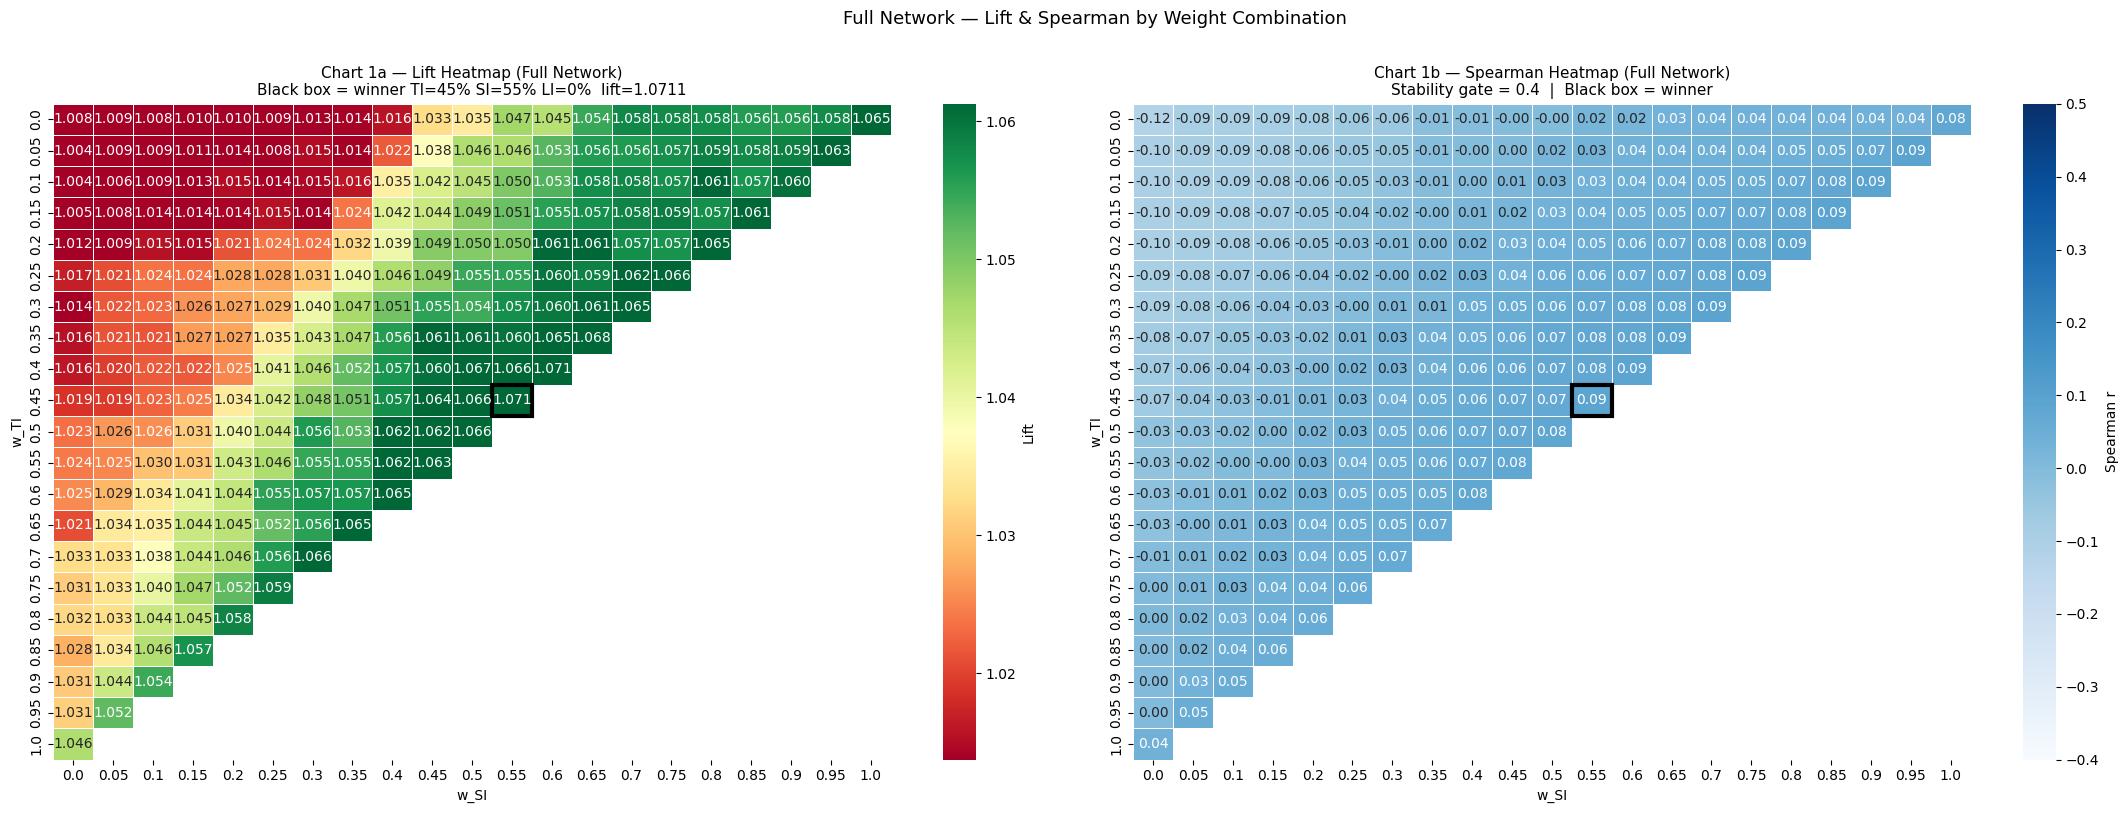

Saved: net_heatmaps.png


In [12]:
res_n = net_result['results']; w_n = net_result['winner']

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# 1a — Lift heatmap
pivot_l = res_n.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')
sns.heatmap(pivot_l, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.4, ax=axes[0],
            vmin=res_n.lift.quantile(0.10), vmax=res_n.lift.quantile(0.90),
            cbar_kws={'label':'Lift'})
w_ti_v = list(pivot_l.index); w_si_v = list(pivot_l.columns)
try:
    ri = min(range(len(w_ti_v)), key=lambda i: abs(w_ti_v[i]-w_n.w_TI))
    ci = min(range(len(w_si_v)), key=lambda i: abs(w_si_v[i]-w_n.w_SI))
    axes[0].add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='black',lw=3))
except: pass
axes[0].set_title(f'Chart 1a — Lift Heatmap (Full Network)\n'
                  f'Black box = winner TI={w_n.w_TI:.0%} SI={w_n.w_SI:.0%} LI={w_n.w_LI:.0%}  lift={w_n.lift:.4f}',
                  fontsize=11)
axes[0].set_xlabel('w_SI'); axes[0].set_ylabel('w_TI')

# 1b — Spearman heatmap
pivot_s = res_n.pivot_table(values='spearman', index='w_TI', columns='w_SI', aggfunc='max')
sns.heatmap(pivot_s, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, ax=axes[1], vmin=-0.4, vmax=0.5,
            cbar_kws={'label':'Spearman r'})
try:
    axes[1].add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='black',lw=3))
except: pass
axes[1].set_title(f'Chart 1b — Spearman Heatmap (Full Network)\n'
                  f'Stability gate = {SPEARMAN_THRESHOLD}  |  Black box = winner', fontsize=11)
axes[1].set_xlabel('w_SI'); axes[1].set_ylabel('w_TI')

plt.suptitle('Full Network — Lift & Spearman by Weight Combination', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('net_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: net_heatmaps.png')


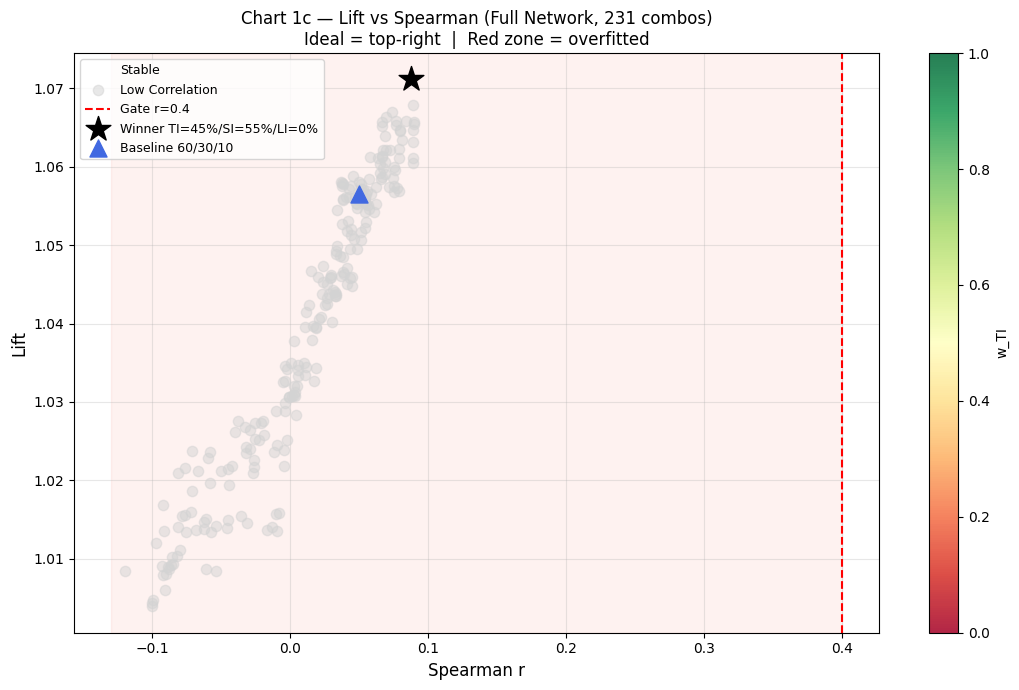

Saved: net_scatter.png


In [13]:
# 1c — Lift vs Spearman scatter
fig, ax = plt.subplots(figsize=(11,7))
stable_r   = res_n[res_n.spearman >= SPEARMAN_THRESHOLD]
unstable_r = res_n[res_n.spearman <  SPEARMAN_THRESHOLD]
sc = ax.scatter(stable_r.spearman, stable_r.lift, c=stable_r.w_TI,
                cmap='RdYlGn', s=55, alpha=0.85, zorder=3, label='Stable')
ax.scatter(unstable_r.spearman, unstable_r.lift, c='lightgrey',
           s=55, alpha=0.5, zorder=2, label='Low Correlation')
plt.colorbar(sc, ax=ax, label='w_TI')
ax.axvline(SPEARMAN_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Gate r={SPEARMAN_THRESHOLD}')
ax.scatter([w_n.spearman],[w_n.lift], marker='*', color='black', s=350, zorder=6,
           label=f'Winner TI={w_n.w_TI:.0%}/SI={w_n.w_SI:.0%}/LI={w_n.w_LI:.0%}')
bl_n = net_result['baseline']
if bl_n is not None:
    ax.scatter([bl_n.spearman],[bl_n.lift], marker='^', color='royalblue', s=150, zorder=6,
               label='Baseline 60/30/10')
ax.axvspan(res_n.spearman.min()-0.01, SPEARMAN_THRESHOLD, color='salmon', alpha=0.10)
ax.set_xlabel('Spearman r', fontsize=12); ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Chart 1c — Lift vs Spearman (Full Network, 231 combos)\n'
             'Ideal = top-right  |  Red zone = overfitted', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('net_scatter.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: net_scatter.png')


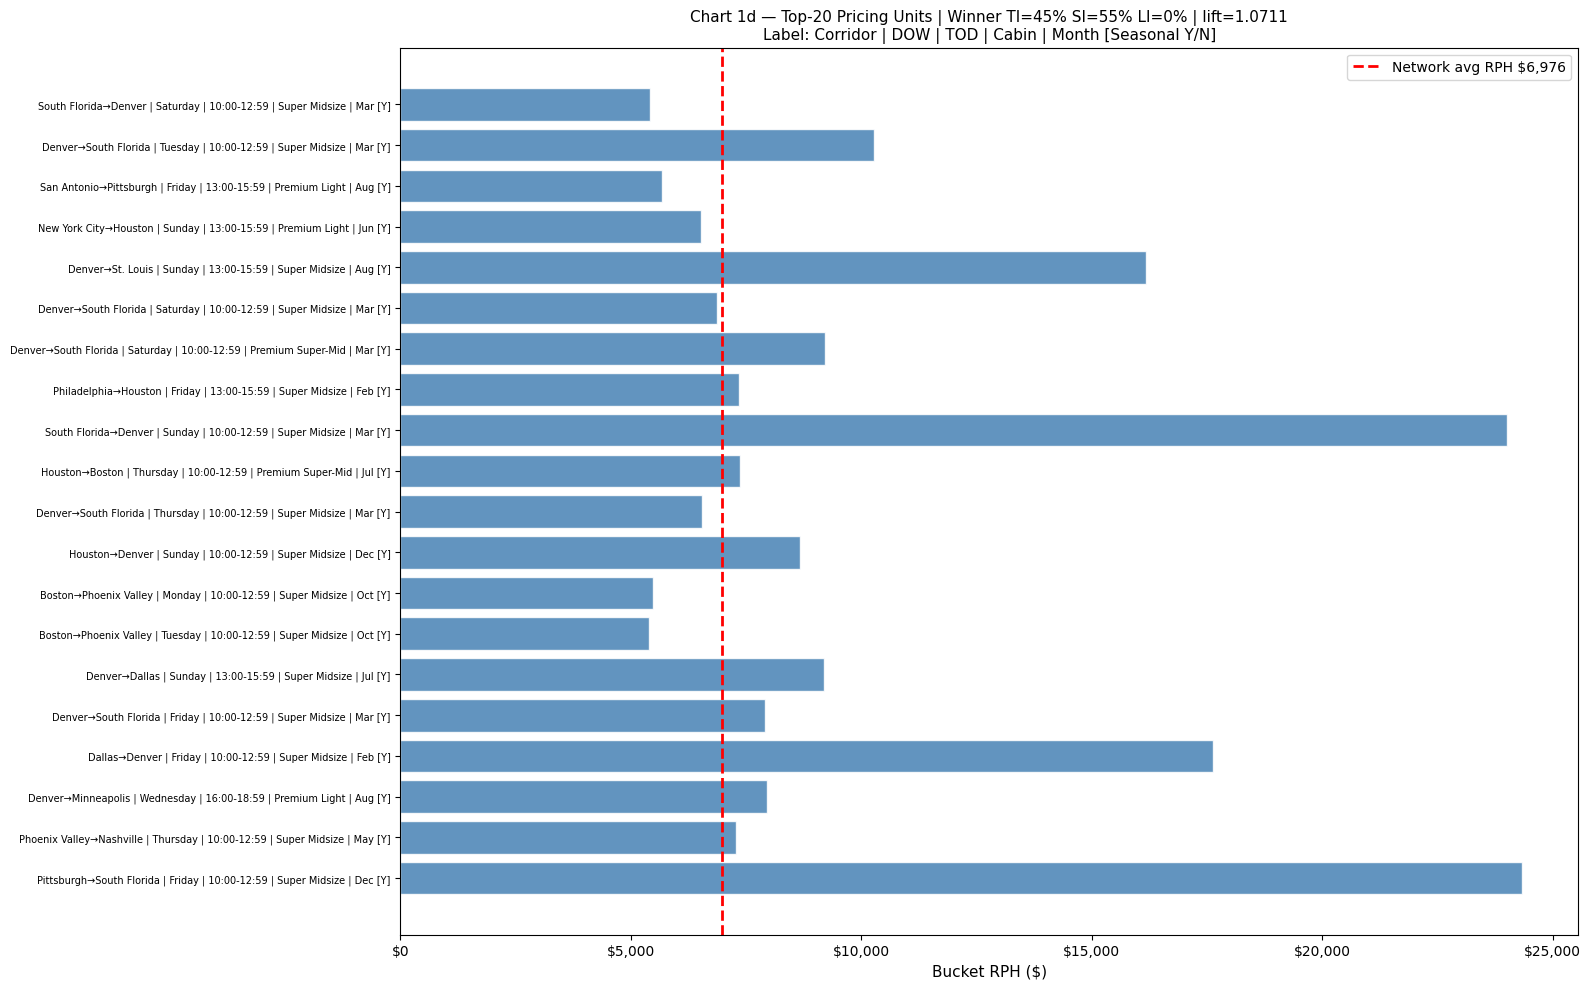

Saved: net_top_units.png


In [14]:
# 1d — Top-decile units bar chart
fig, ax = plt.subplots(figsize=(16,10))
top_n = net_top.copy()
top_n['label'] = (top_n['corridor'].str.replace('->','→',regex=False)
                  + ' | ' + top_n['DOW'].astype(str)
                  + ' | ' + top_n['TOD'].astype(str)
                  + ' | ' + top_n[CABIN_COL].astype(str)
                  + ' | ' + top_n['month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}).fillna(top_n['month'].astype(str))
                  + ' [' + top_n['Seasonal'] + ']')
ax.barh(range(len(top_n)), top_n['bucket_rph'], color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(NETWORK_AVG_RPH, color='red', ls='--', lw=2,
           label=f'Network avg RPH ${NETWORK_AVG_RPH:,.0f}')
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels(top_n['label'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Bucket RPH ($)', fontsize=11)
ax.set_title(f'Chart 1d — Top-20 Pricing Units | Winner TI={w_n.w_TI:.0%} SI={w_n.w_SI:.0%} '
             f'LI={w_n.w_LI:.0%} | lift={w_n.lift:.4f}\n'
             f'Label: Corridor | DOW | TOD | Cabin | Month [Seasonal Y/N]', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('net_top_units.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: net_top_units.png')


---
# Part 2 — Light Jet Only

Grid search run on Light Jet buckets only.  
Signals re-normalised **within Light Jet range** for a fair within-cabin comparison.  
Benchmark = Light Jet average RPH (not the full network).

> A Light Jet customer and a Super Midsize customer have different booking patterns  
> and price sensitivities — optimal weights may differ between cabins.


In [15]:
lj_bkts = buckets[buckets[CABIN_COL] == 'Light'].copy()
lj_avg_rph = lj_bkts['total_final_revenue'].sum() / lj_bkts['total_hours'].sum()
lj_hours   = lj_bkts['total_hours'].sum()
print(f'Light Jet buckets : {len(lj_bkts):,}  |  avg RPH=${lj_avg_rph:,.0f}  |  hours={lj_hours:,.0f}')

lj_result = run_grid_search(
    lj_bkts, 'Light Jet',
    benchmark_rph=lj_avg_rph, benchmark_hours=lj_hours,
    W=W, SPEARMAN_THRESHOLD=SPEARMAN_THRESHOLD,
    TOP_DECILE_HOURS_PCT=TOP_DECILE_HOURS_PCT,
)


Light Jet buckets : 2,449  |  avg RPH=$5,852  |  hours=27,909
[Light Jet]  420 ms  |  lift 0.9527–1.0580  |  Spearman -0.122–0.030  |  stable: 0/231
  Winner: TI=50%  SI=50%  LI=0%  lift=1.0580  (WINNER (Fallback ≥ -0.028))
  Baseline (60/30/10): lift=1.0298  rank=#11  improvement=+2.74%


### Top-20 Weight Combinations — Light Jet


In [16]:
res_lj = lj_result['results']; w_lj = lj_result['winner']; bl_lj = lj_result['baseline']

t20 = res_lj.head(20).copy()
t20.insert(0,'Rank', range(1,21))
t20['w_TI%'] = (t20.w_TI*100).astype(int).astype(str)+'%'
t20['w_SI%'] = (t20.w_SI*100).astype(int).astype(str)+'%'
t20['w_LI%'] = (t20.w_LI*100).astype(int).astype(str)+'%'
t20['Lift']     = t20.lift.apply(lambda x: f'{x:.4f}')
t20['Spearman'] = t20.spearman.apply(lambda x: f'{x:.3f}')
t20['Top RPH']  = t20.top_decile_rph.apply(lambda x: f'${x:,.0f}')
display(t20[['Rank','w_TI%','w_SI%','w_LI%','Lift','Spearman','Top RPH','verdict']])

print(f'\nLight Jet avg RPH : ${lj_avg_rph:,.0f}')
print(f'Winner  TI={w_lj.w_TI:.0%} SI={w_lj.w_SI:.0%} LI={w_lj.w_LI:.0%}  '
      f'lift={w_lj.lift:.4f}  top-RPH=${w_lj.top_decile_rph:,.0f}')
if bl_lj is not None:
    bm_lj = lj_result['bm_mask']
    print(f'Baseline(60/30/10) lift={bl_lj.lift:.4f}  rank=#{res_lj[bm_lj].index[0]+1}  '
          f'improvement=+{(w_lj.lift-bl_lj.lift)/bl_lj.lift*100:.2f}%')


,Rank,w_TI%,w_SI%,w_LI%,Lift,Spearman,Top RPH,verdict
0,1,50%,50%,0%,1.0580,0.022,"$6,192",WINNER (Fallback ≥ -0.028)
1,2,55%,45%,0%,1.0485,0.022,"$6,136",Low Corr
2,3,45%,55%,0%,1.0445,0.021,"$6,113",Low Corr
3,4,45%,50%,5%,1.0412,0.010,"$6,093",Low Corr
4,5,60%,40%,0%,1.0407,0.022,"$6,090",Low Corr
5,6,50%,45%,5%,1.0401,0.012,"$6,087",Low Corr
6,7,75%,25%,0%,1.0349,0.030,"$6,057",Low Corr
7,8,70%,30%,0%,1.0332,0.029,"$6,047",Low Corr
8,9,45%,45%,10%,1.0301,0.007,"$6,028",Low Corr
9,10,40%,60%,0%,1.0299,0.017,"$6,027",Low Corr



Light Jet avg RPH : $5,852
Winner  TI=50% SI=50% LI=0%  lift=1.0580  top-RPH=$6,192
Baseline(60/30/10) lift=1.0298  rank=#11  improvement=+2.74%


### Top-Decile Pricing Units — Light Jet


In [17]:
lj_top = top_decile_table(lj_result['seg_buckets'], w_lj, TOP_DECILE_HOURS_PCT, lj_hours)
display_top_table(lj_top, 'Light Jet — Top-20 Pricing Units (Corridor + DOW + TOD + Month + Seasonal)')


Light Jet — Top-20 Pricing Units (Corridor + DOW + TOD + Month + Seasonal)


,Corridor,DOW,TOD,Cabin,Month,Seasonal,Flights,RPH,Score
1,Pittsburgh->Boston,Sunday,07:00-09:59,Light,Nov,N,6,"$6,241",0.875
2,Dallas->Boston,Thursday,10:00-12:59,Light,Jun,Y,5,"$6,228",0.812
3,Boston->Charlotte,Sunday,10:00-12:59,Light,Aug,Y,15,"$5,003",0.800
4,Denver->Dallas,Sunday,13:00-15:59,Light,Jul,Y,12,"$2,669",0.800
5,Pittsburgh->New York City,Thursday,13:00-15:59,Light,Oct,Y,7,"$7,264",0.750
6,Chicago->South Florida,Monday,10:00-12:59,Light,Dec,Y,6,"$6,444",0.750
7,Charlotte->Nashville,Thursday,13:00-15:59,Light,Mar,Y,7,"$10,812",0.750
8,Charlotte->Philadelphia,Sunday,10:00-12:59,Light,Jun,Y,5,"$5,440",0.750
9,Pittsburgh->Boston,Sunday,10:00-12:59,Light,Jul,Y,6,"$5,382",0.750
10,Chicago->South Florida,Sunday,10:00-12:59,Light,Dec,Y,5,"$4,743",0.750


### Charts — Light Jet
**Chart 2a:** Lift heatmap  |  **Chart 2b:** Spearman heatmap  
**Chart 2c:** Lift vs Spearman scatter  |  **Chart 2d:** Top-decile units bar chart


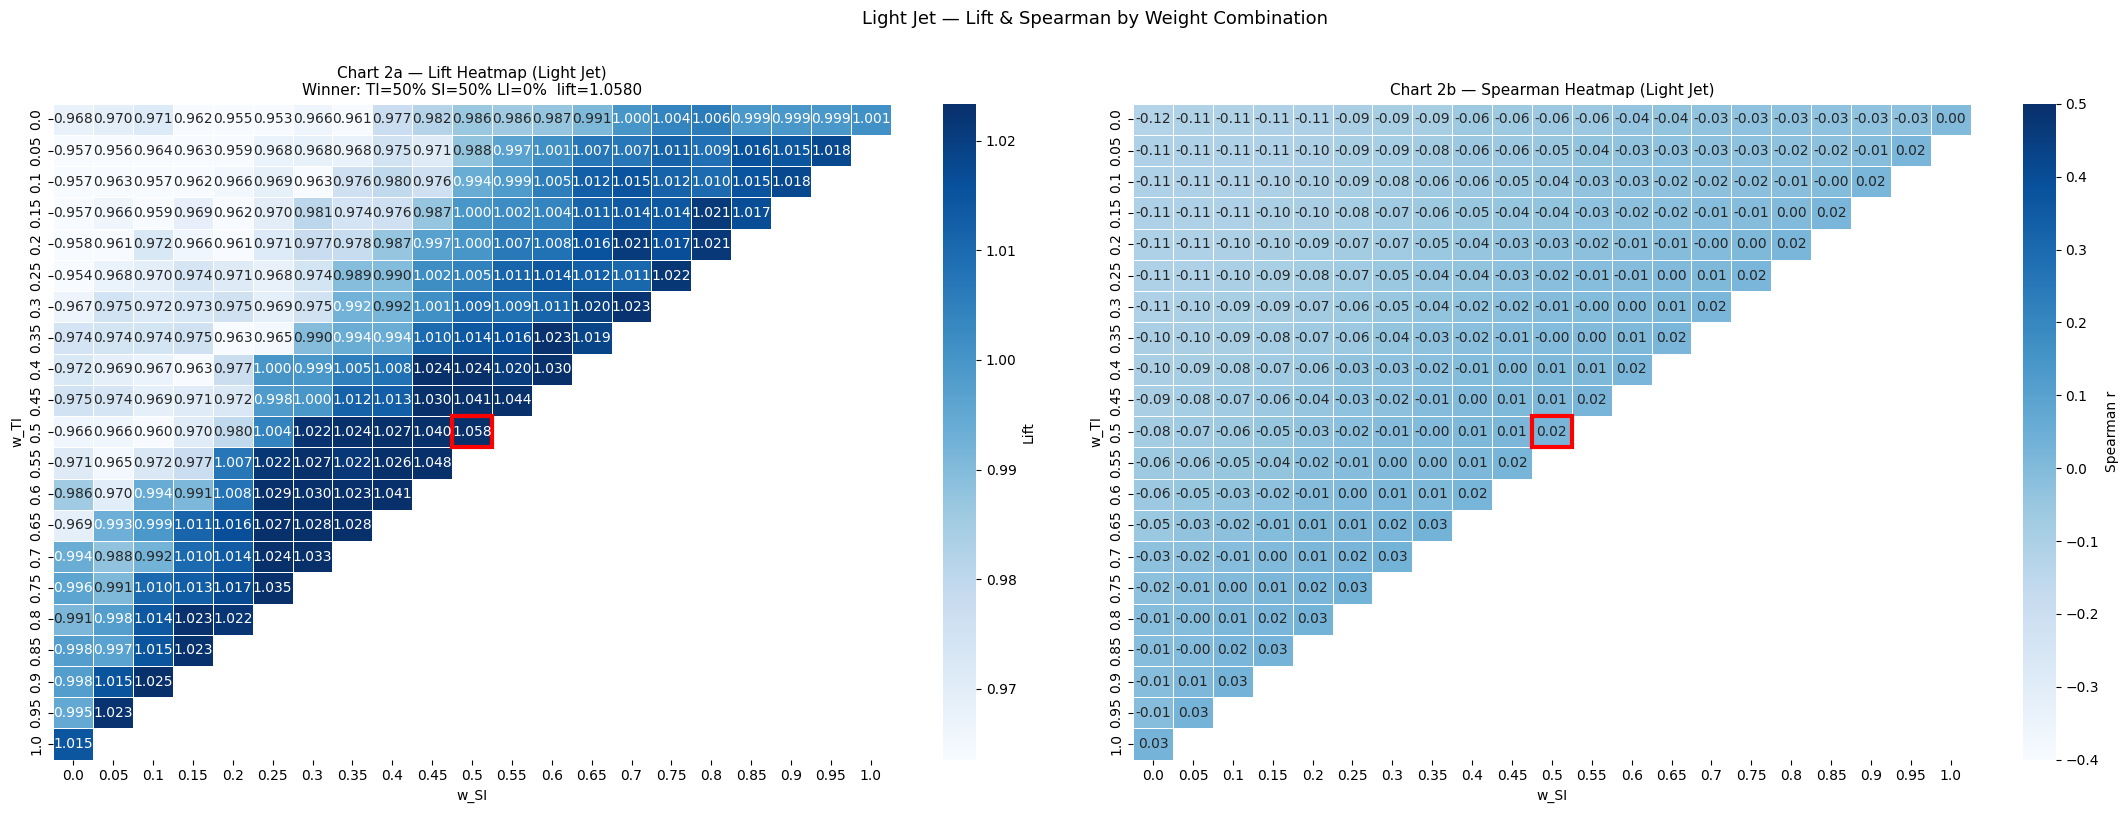

Saved: lj_heatmaps.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

pivot_lj_l = res_lj.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')
sns.heatmap(pivot_lj_l, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.4, ax=axes[0],
            vmin=res_lj.lift.quantile(0.10), vmax=res_lj.lift.quantile(0.90),
            cbar_kws={'label':'Lift'})
w_ti_v = list(pivot_lj_l.index); w_si_v = list(pivot_lj_l.columns)
try:
    ri = min(range(len(w_ti_v)), key=lambda i: abs(w_ti_v[i]-w_lj.w_TI))
    ci = min(range(len(w_si_v)), key=lambda i: abs(w_si_v[i]-w_lj.w_SI))
    axes[0].add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='red',lw=3))
except: pass
axes[0].set_title(f'Chart 2a — Lift Heatmap (Light Jet)\n'
                  f'Winner: TI={w_lj.w_TI:.0%} SI={w_lj.w_SI:.0%} LI={w_lj.w_LI:.0%}  lift={w_lj.lift:.4f}',
                  fontsize=11)
axes[0].set_xlabel('w_SI'); axes[0].set_ylabel('w_TI')

pivot_lj_s = res_lj.pivot_table(values='spearman', index='w_TI', columns='w_SI', aggfunc='max')
sns.heatmap(pivot_lj_s, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, ax=axes[1], vmin=-0.4, vmax=0.5,
            cbar_kws={'label':'Spearman r'})
try:
    axes[1].add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='red',lw=3))
except: pass
axes[1].set_title(f'Chart 2b — Spearman Heatmap (Light Jet)', fontsize=11)
axes[1].set_xlabel('w_SI'); axes[1].set_ylabel('w_TI')

plt.suptitle('Light Jet — Lift & Spearman by Weight Combination', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lj_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lj_heatmaps.png')


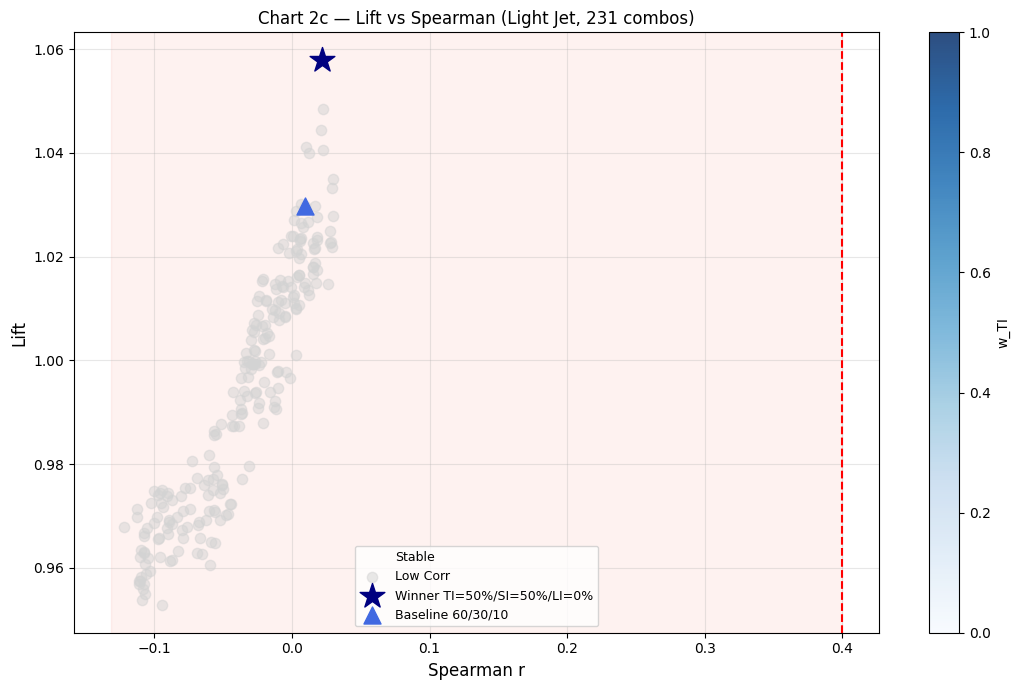

Saved: lj_scatter.png


In [19]:
# Chart 2c — Lift vs Spearman scatter
fig, ax = plt.subplots(figsize=(11,7))
st = res_lj[res_lj.spearman >= SPEARMAN_THRESHOLD]
un = res_lj[res_lj.spearman <  SPEARMAN_THRESHOLD]
sc = ax.scatter(st.spearman, st.lift, c=st.w_TI, cmap='Blues', s=55, alpha=0.85, zorder=3, label='Stable')
ax.scatter(un.spearman, un.lift, c='lightgrey', s=55, alpha=0.5, zorder=2, label='Low Corr')
plt.colorbar(sc, ax=ax, label='w_TI')
ax.axvline(SPEARMAN_THRESHOLD, color='red', ls='--', lw=1.5)
ax.scatter([w_lj.spearman],[w_lj.lift], marker='*', color='navy', s=350, zorder=6,
           label=f'Winner TI={w_lj.w_TI:.0%}/SI={w_lj.w_SI:.0%}/LI={w_lj.w_LI:.0%}')
if bl_lj is not None:
    ax.scatter([bl_lj.spearman],[bl_lj.lift], marker='^', color='royalblue', s=150, zorder=6,
               label='Baseline 60/30/10')
ax.axvspan(res_lj.spearman.min()-0.01, SPEARMAN_THRESHOLD, color='salmon', alpha=0.10)
ax.set_xlabel('Spearman r', fontsize=12); ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Chart 2c — Lift vs Spearman (Light Jet, 231 combos)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lj_scatter.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lj_scatter.png')


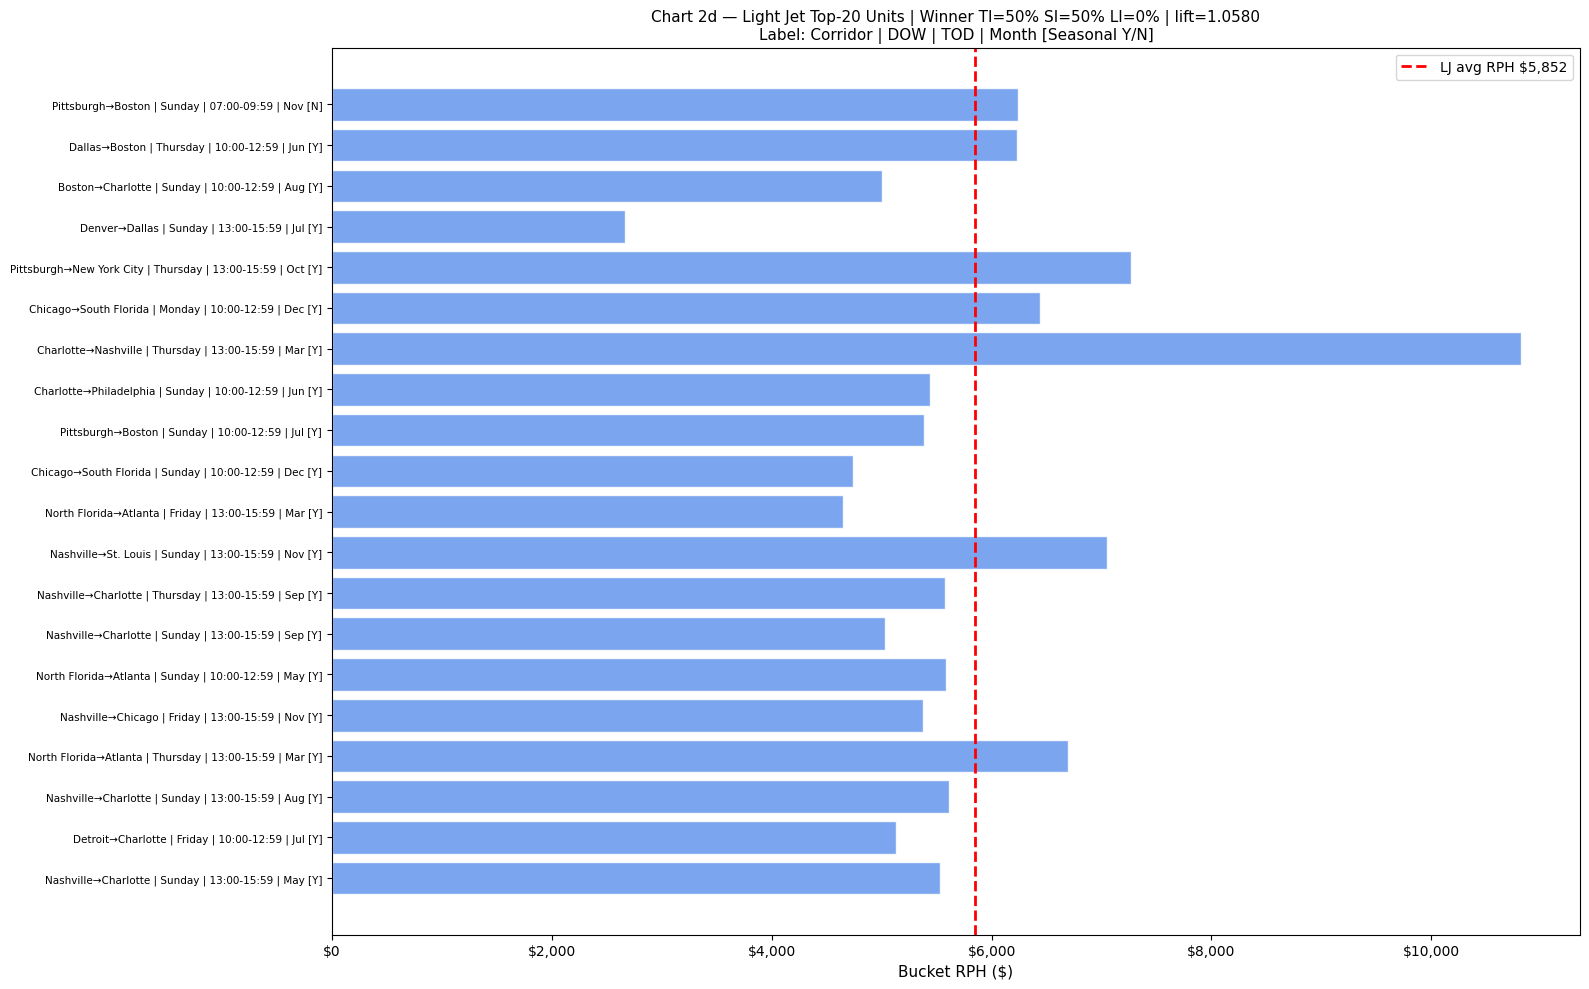

Saved: lj_top_units.png


In [20]:
# Chart 2d — Top-decile units bar chart
fig, ax = plt.subplots(figsize=(16,10))
lj_top['label'] = (lj_top['corridor'].str.replace('->','→',regex=False)
                   + ' | ' + lj_top['DOW'].astype(str)
                   + ' | ' + lj_top['TOD'].astype(str)
                   + ' | ' + lj_top['month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}).fillna(lj_top['month'].astype(str))
                   + ' [' + lj_top['Seasonal'] + ']')
ax.barh(range(len(lj_top)), lj_top['bucket_rph'],
        color='cornflowerblue', edgecolor='white', alpha=0.85)
ax.axvline(lj_avg_rph, color='red', ls='--', lw=2,
           label=f'LJ avg RPH ${lj_avg_rph:,.0f}')
ax.set_yticks(range(len(lj_top)))
ax.set_yticklabels(lj_top['label'], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel('Bucket RPH ($)', fontsize=11)
ax.set_title(f'Chart 2d — Light Jet Top-20 Units | Winner TI={w_lj.w_TI:.0%} '
             f'SI={w_lj.w_SI:.0%} LI={w_lj.w_LI:.0%} | lift={w_lj.lift:.4f}\n'
             f'Label: Corridor | DOW | TOD | Month [Seasonal Y/N]', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('lj_top_units.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lj_top_units.png')


---
# Part 3 — Super Midsize Only

Identical methodology to Part 2, applied exclusively to Super Midsize buckets.  
Benchmark = Super Midsize average RPH.


In [21]:
sm_bkts = buckets[buckets[CABIN_COL] == 'Super Midsize'].copy()
sm_avg_rph = sm_bkts['total_final_revenue'].sum() / sm_bkts['total_hours'].sum()
sm_hours   = sm_bkts['total_hours'].sum()
print(f'Super Midsize buckets : {len(sm_bkts):,}  |  avg RPH=${sm_avg_rph:,.0f}  |  hours={sm_hours:,.0f}')

sm_result = run_grid_search(
    sm_bkts, 'Super Midsize',
    benchmark_rph=sm_avg_rph, benchmark_hours=sm_hours,
    W=W, SPEARMAN_THRESHOLD=SPEARMAN_THRESHOLD,
    TOP_DECILE_HOURS_PCT=TOP_DECILE_HOURS_PCT,
)


Super Midsize buckets : 3,107  |  avg RPH=$7,960  |  hours=56,332
[Super Midsize]  283 ms  |  lift 0.8670–1.0254  |  Spearman -0.215–0.094  |  stable: 0/231
  Winner: TI=25%  SI=75%  LI=0%  lift=1.0254  (WINNER (Fallback ≥ -0.091))
  Baseline (60/30/10): lift=0.9429  rank=#70  improvement=+8.74%


### Top-20 Weight Combinations — Super Midsize


In [22]:
res_sm = sm_result['results']; w_sm = sm_result['winner']; bl_sm = sm_result['baseline']

t20 = res_sm.head(20).copy()
t20.insert(0,'Rank', range(1,21))
t20['w_TI%'] = (t20.w_TI*100).astype(int).astype(str)+'%'
t20['w_SI%'] = (t20.w_SI*100).astype(int).astype(str)+'%'
t20['w_LI%'] = (t20.w_LI*100).astype(int).astype(str)+'%'
t20['Lift']     = t20.lift.apply(lambda x: f'{x:.4f}')
t20['Spearman'] = t20.spearman.apply(lambda x: f'{x:.3f}')
t20['Top RPH']  = t20.top_decile_rph.apply(lambda x: f'${x:,.0f}')
display(t20[['Rank','w_TI%','w_SI%','w_LI%','Lift','Spearman','Top RPH','verdict']])

print(f'\nSuper Midsize avg RPH : ${sm_avg_rph:,.0f}')
print(f'Winner  TI={w_sm.w_TI:.0%} SI={w_sm.w_SI:.0%} LI={w_sm.w_LI:.0%}  '
      f'lift={w_sm.lift:.4f}  top-RPH=${w_sm.top_decile_rph:,.0f}')
if bl_sm is not None:
    bm_sm = sm_result['bm_mask']
    print(f'Baseline(60/30/10) lift={bl_sm.lift:.4f}  rank=#{res_sm[bm_sm].index[0]+1}  '
          f'improvement=+{(w_sm.lift-bl_sm.lift)/bl_sm.lift*100:.2f}%')


,Rank,w_TI%,w_SI%,w_LI%,Lift,Spearman,Top RPH,verdict
0,1,25%,75%,0%,1.0254,0.070,"$8,162",WINNER (Fallback ≥ -0.091)
1,2,30%,70%,0%,1.0239,0.066,"$8,150",Low Corr
2,3,5%,95%,0%,1.0228,0.073,"$8,141",Low Corr
3,4,10%,90%,0%,1.0228,0.072,"$8,141",Low Corr
4,5,15%,85%,0%,1.0215,0.072,"$8,130",Low Corr
5,6,20%,80%,0%,1.0210,0.071,"$8,127",Low Corr
6,7,35%,65%,0%,1.0172,0.059,"$8,097",Low Corr
7,8,30%,65%,5%,1.0171,0.045,"$8,095",Low Corr
8,9,25%,70%,5%,1.0163,0.053,"$8,090",Low Corr
9,10,20%,75%,5%,1.0161,0.055,"$8,088",Low Corr



Super Midsize avg RPH : $7,960
Winner  TI=25% SI=75% LI=0%  lift=1.0254  top-RPH=$8,162
Baseline(60/30/10) lift=0.9429  rank=#70  improvement=+8.74%


### Top-Decile Pricing Units — Super Midsize


In [23]:
sm_top = top_decile_table(sm_result['seg_buckets'], w_sm, TOP_DECILE_HOURS_PCT, sm_hours)
display_top_table(sm_top, 'Super Midsize — Top-20 Pricing Units (Corridor + DOW + TOD + Month + Seasonal)')


Super Midsize — Top-20 Pricing Units (Corridor + DOW + TOD + Month + Seasonal)


,Corridor,DOW,TOD,Cabin,Month,Seasonal,Flights,RPH,Score
1,South Florida->Denver,Saturday,10:00-12:59,Super Midsize,Mar,Y,9,"$5,427",0.944
2,South Florida->Denver,Sunday,10:00-12:59,Super Midsize,Mar,Y,7,"$23,996",0.917
3,Denver->South Florida,Tuesday,10:00-12:59,Super Midsize,Mar,Y,6,"$10,268",0.917
4,Denver->St. Louis,Sunday,13:00-15:59,Super Midsize,Aug,Y,6,"$16,175",0.917
5,Philadelphia->Houston,Friday,13:00-15:59,Super Midsize,Feb,Y,8,"$7,352",0.917
6,Denver->South Florida,Saturday,10:00-12:59,Super Midsize,Mar,Y,21,"$6,872",0.917
7,Denver->South Florida,Thursday,10:00-12:59,Super Midsize,Mar,Y,9,"$6,544",0.889
8,Phoenix Valley->Nashville,Thursday,10:00-12:59,Super Midsize,May,Y,8,"$7,291",0.889
9,Phoenix Valley->Nashville,Wednesday,13:00-15:59,Super Midsize,May,Y,8,"$5,536",0.889
10,Boston->Phoenix Valley,Monday,10:00-12:59,Super Midsize,Oct,Y,5,"$5,489",0.889


### Charts — Super Midsize
**Chart 3a:** Lift heatmap  |  **Chart 3b:** Spearman heatmap  
**Chart 3c:** Lift vs Spearman scatter  |  **Chart 3d:** Top-decile units bar chart


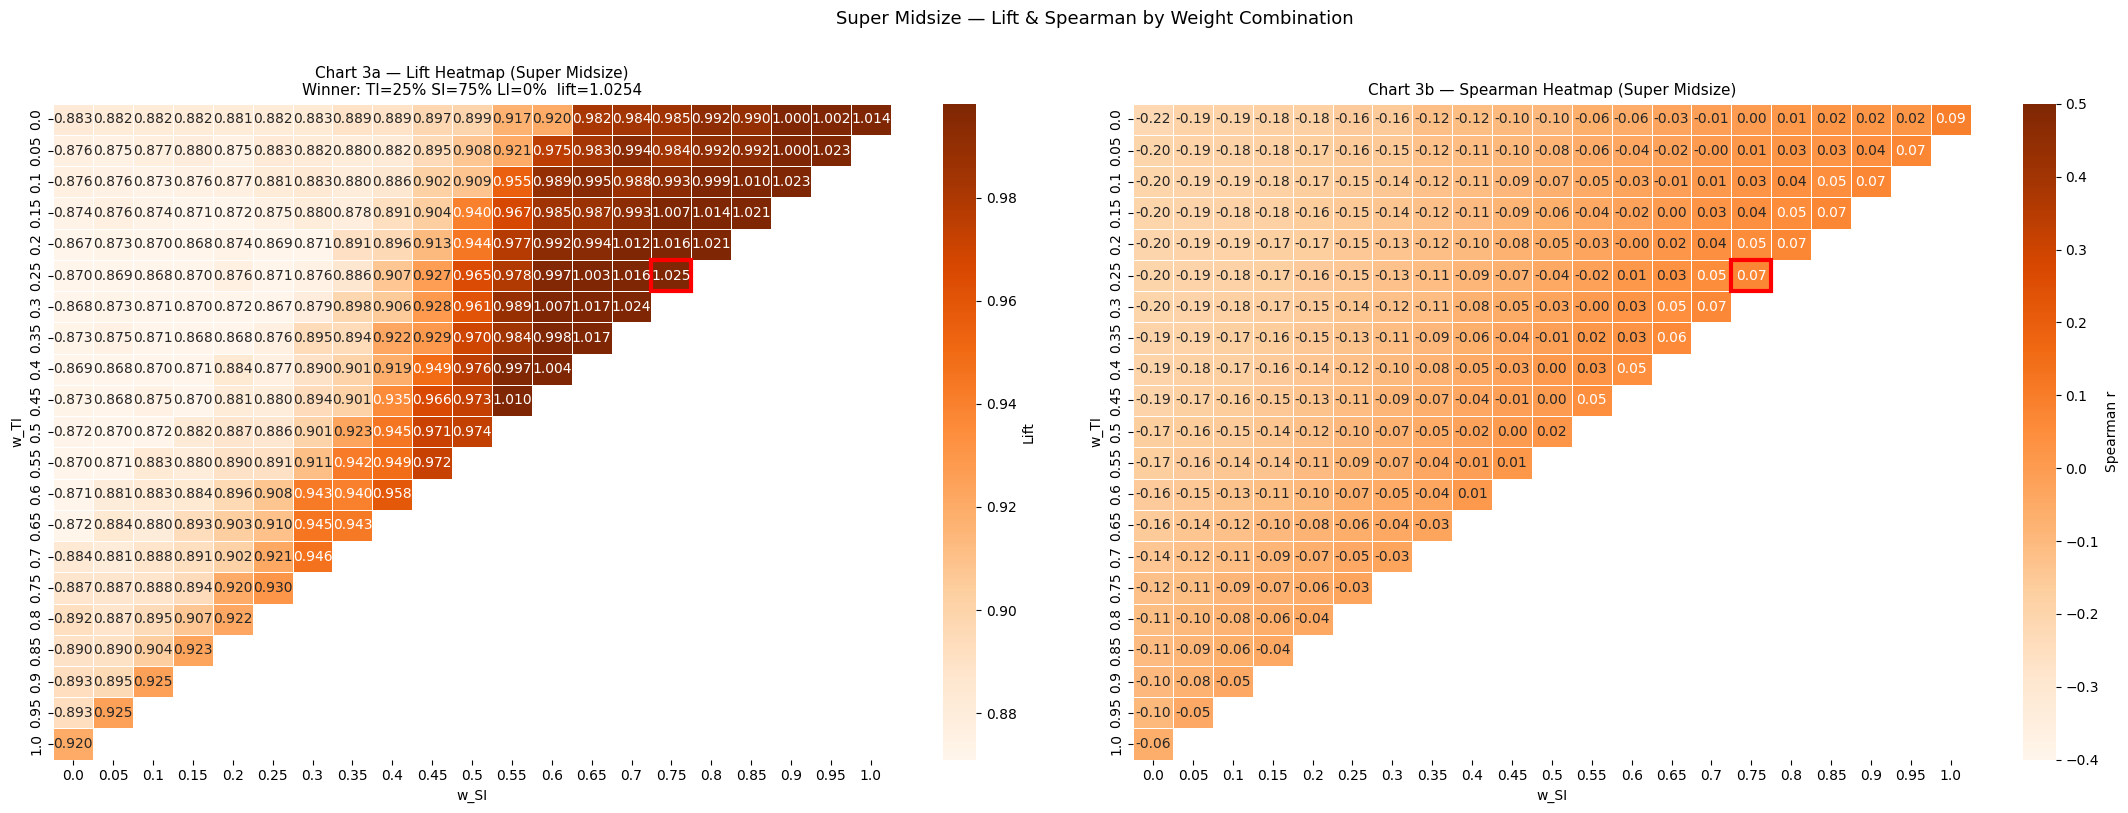

Saved: sm_heatmaps.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

pivot_sm_l = res_sm.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')
sns.heatmap(pivot_sm_l, annot=True, fmt='.3f', cmap='Oranges',
            linewidths=0.4, ax=axes[0],
            vmin=res_sm.lift.quantile(0.10), vmax=res_sm.lift.quantile(0.90),
            cbar_kws={'label':'Lift'})
w_ti_v = list(pivot_sm_l.index); w_si_v = list(pivot_sm_l.columns)
try:
    ri = min(range(len(w_ti_v)), key=lambda i: abs(w_ti_v[i]-w_sm.w_TI))
    ci = min(range(len(w_si_v)), key=lambda i: abs(w_si_v[i]-w_sm.w_SI))
    axes[0].add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='red',lw=3))
except: pass
axes[0].set_title(f'Chart 3a — Lift Heatmap (Super Midsize)\n'
                  f'Winner: TI={w_sm.w_TI:.0%} SI={w_sm.w_SI:.0%} LI={w_sm.w_LI:.0%}  lift={w_sm.lift:.4f}',
                  fontsize=11)
axes[0].set_xlabel('w_SI'); axes[0].set_ylabel('w_TI')

pivot_sm_s = res_sm.pivot_table(values='spearman', index='w_TI', columns='w_SI', aggfunc='max')
sns.heatmap(pivot_sm_s, annot=True, fmt='.2f', cmap='Oranges',
            linewidths=0.4, ax=axes[1], vmin=-0.4, vmax=0.5,
            cbar_kws={'label':'Spearman r'})
try:
    axes[1].add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='red',lw=3))
except: pass
axes[1].set_title(f'Chart 3b — Spearman Heatmap (Super Midsize)', fontsize=11)
axes[1].set_xlabel('w_SI'); axes[1].set_ylabel('w_TI')

plt.suptitle('Super Midsize — Lift & Spearman by Weight Combination', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sm_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: sm_heatmaps.png')


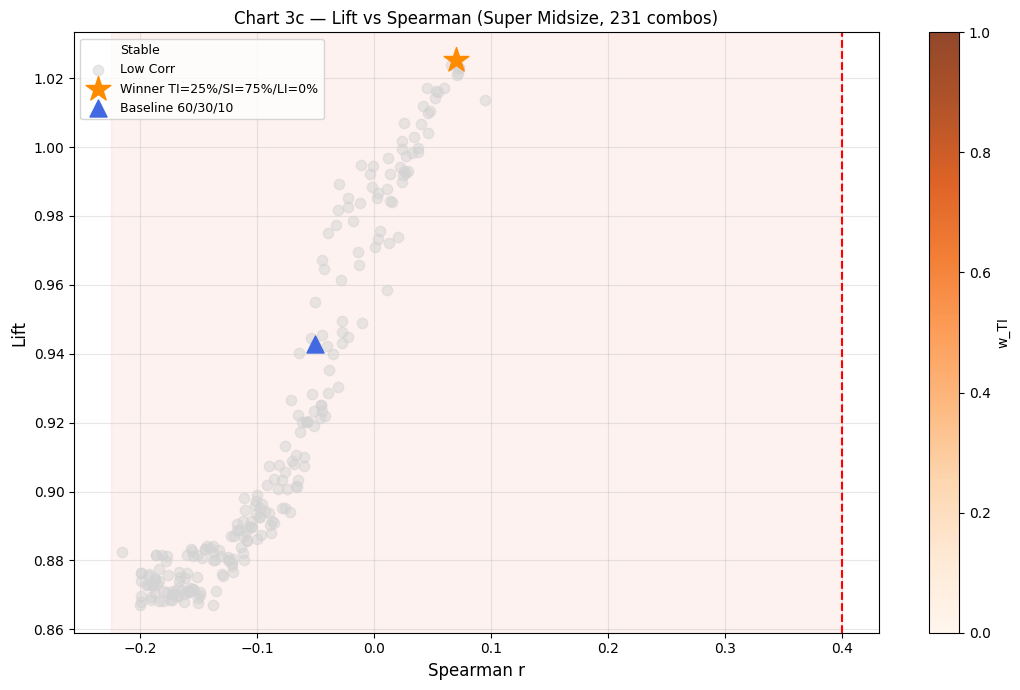

Saved: sm_scatter.png


In [25]:
# Chart 3c — Lift vs Spearman scatter
fig, ax = plt.subplots(figsize=(11,7))
st = res_sm[res_sm.spearman >= SPEARMAN_THRESHOLD]
un = res_sm[res_sm.spearman <  SPEARMAN_THRESHOLD]
sc = ax.scatter(st.spearman, st.lift, c=st.w_TI, cmap='Oranges', s=55, alpha=0.85, zorder=3, label='Stable')
ax.scatter(un.spearman, un.lift, c='lightgrey', s=55, alpha=0.5, zorder=2, label='Low Corr')
plt.colorbar(sc, ax=ax, label='w_TI')
ax.axvline(SPEARMAN_THRESHOLD, color='red', ls='--', lw=1.5)
ax.scatter([w_sm.spearman],[w_sm.lift], marker='*', color='darkorange', s=350, zorder=6,
           label=f'Winner TI={w_sm.w_TI:.0%}/SI={w_sm.w_SI:.0%}/LI={w_sm.w_LI:.0%}')
if bl_sm is not None:
    ax.scatter([bl_sm.spearman],[bl_sm.lift], marker='^', color='royalblue', s=150, zorder=6,
               label='Baseline 60/30/10')
ax.axvspan(res_sm.spearman.min()-0.01, SPEARMAN_THRESHOLD, color='salmon', alpha=0.10)
ax.set_xlabel('Spearman r', fontsize=12); ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Chart 3c — Lift vs Spearman (Super Midsize, 231 combos)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sm_scatter.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: sm_scatter.png')


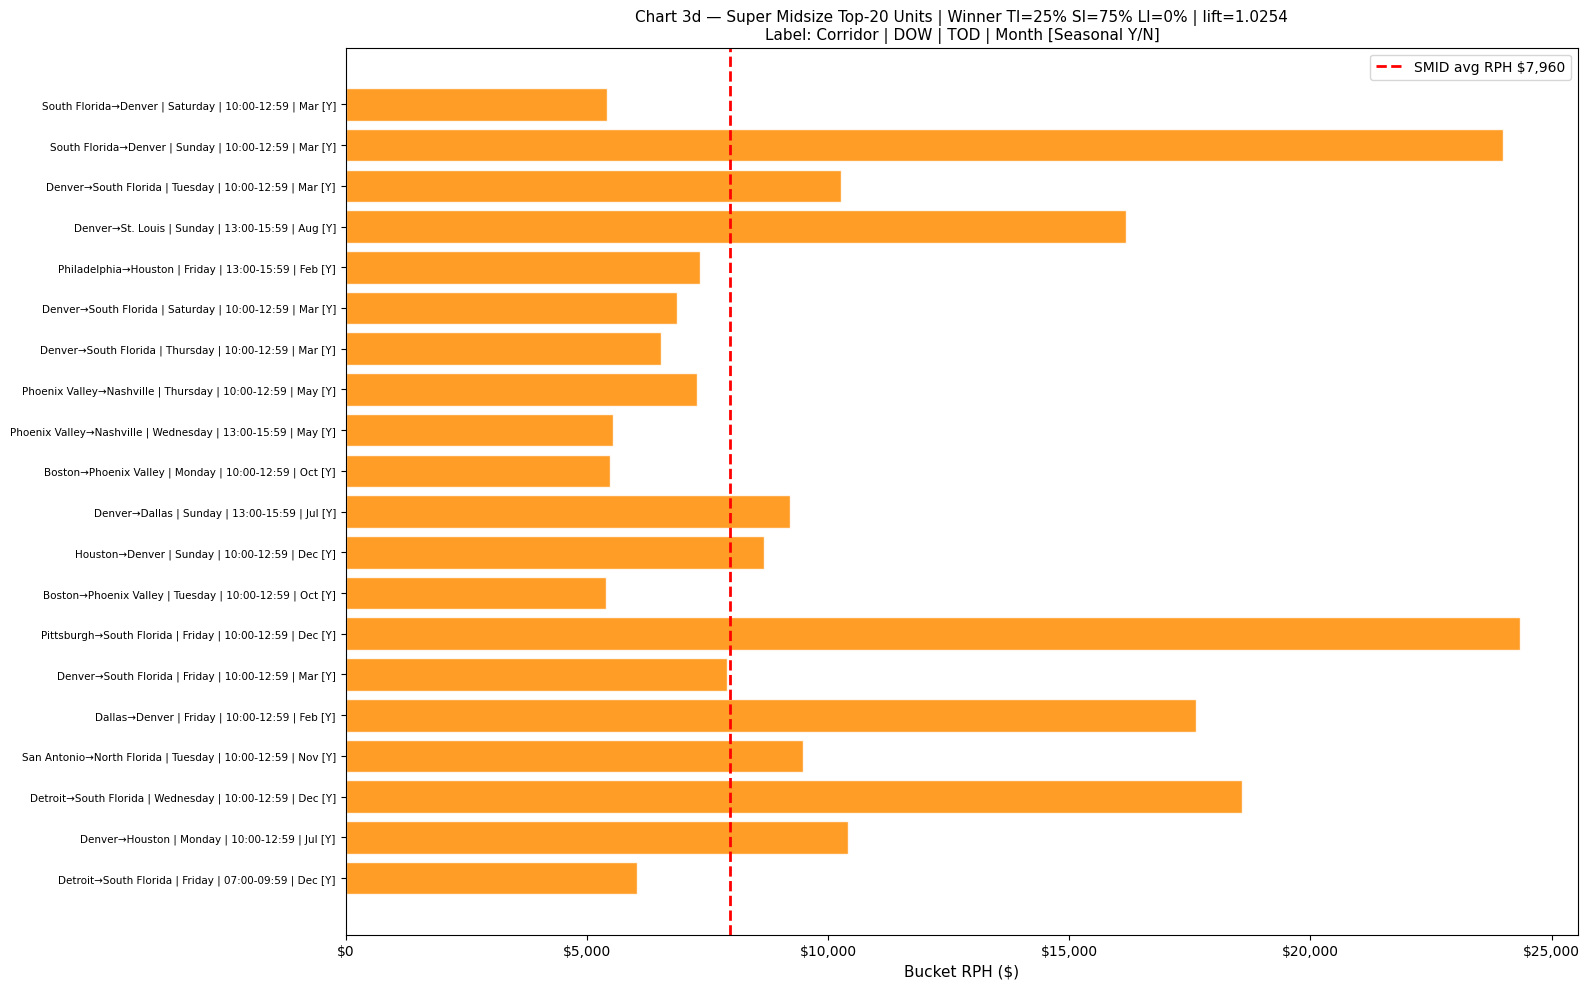

Saved: sm_top_units.png


In [26]:
# Chart 3d — Top-decile units bar chart
fig, ax = plt.subplots(figsize=(16,10))
sm_top['label'] = (sm_top['corridor'].str.replace('->','→',regex=False)
                   + ' | ' + sm_top['DOW'].astype(str)
                   + ' | ' + sm_top['TOD'].astype(str)
                   + ' | ' + sm_top['month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}).fillna(sm_top['month'].astype(str))
                   + ' [' + sm_top['Seasonal'] + ']')
ax.barh(range(len(sm_top)), sm_top['bucket_rph'],
        color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(sm_avg_rph, color='red', ls='--', lw=2,
           label=f'SMID avg RPH ${sm_avg_rph:,.0f}')
ax.set_yticks(range(len(sm_top)))
ax.set_yticklabels(sm_top['label'], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel('Bucket RPH ($)', fontsize=11)
ax.set_title(f'Chart 3d — Super Midsize Top-20 Units | Winner TI={w_sm.w_TI:.0%} '
             f'SI={w_sm.w_SI:.0%} LI={w_sm.w_LI:.0%} | lift={w_sm.lift:.4f}\n'
             f'Label: Corridor | DOW | TOD | Month [Seasonal Y/N]', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('sm_top_units.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: sm_top_units.png')


---
## LJ vs SMID — Side-by-Side Comparison

| | Light Jet | Super Midsize |
|--|-----------|---------------|
| **Optimal w_TI** | ? | ? |
| **Optimal w_SI** | ? | ? |
| **Optimal w_LI** | ? | ? |
| **Winner Lift** | ? | ? |
| **vs Baseline** | ? | ? |

Chart 4: side-by-side lift heatmaps  
Chart 5: winner weight bar chart  
Chart 6: lift distribution comparison


In [27]:
# Summary table
rows = []
for label, sr in [('Light Jet', lj_result), ('Super Midsize', sm_result)]:
    w  = sr['winner']; bl = sr['baseline']
    bm = sr['bm_mask']; res = sr['results']
    bl_lift = bl.lift if bl is not None else None
    bl_rank = res[bm].index[0]+1 if bl is not None else None
    rows.append({
        'Segment'         : label,
        'Flights'         : f"{sr['n_flights']:,}",
        'Buckets'         : f"{sr['n_buckets']:,}",
        'Segment avg RPH' : f"${sr['benchmark_rph']:,.0f}",
        'Optimal w_TI'    : f"{w.w_TI:.0%}",
        'Optimal w_SI'    : f"{w.w_SI:.0%}",
        'Optimal w_LI'    : f"{w.w_LI:.0%}",
        'Winner Lift'     : f"{w.lift:.4f}",
        'Top-decile RPH'  : f"${w.top_decile_rph:,.0f}",
        'Spearman'        : f"{w.spearman:.3f}",
        'Baseline Lift'   : f"{bl_lift:.4f}" if bl_lift else 'n/a',
        'Baseline Rank'   : f"#{bl_rank}" if bl_rank else 'n/a',
        'Improvement'     : f"+{(w.lift-bl_lift)/bl_lift*100:.2f}%" if bl_lift else 'n/a',
    })
summary_df = pd.DataFrame(rows).set_index('Segment')
display(summary_df.T)


Segment,Light Jet,Super Midsize
Flights,"15,898","22,077"
Buckets,"2,449","3,107"
Segment avg RPH,"$5,852","$7,960"
Optimal w_TI,50%,25%
Optimal w_SI,50%,75%
Optimal w_LI,0%,0%
Winner Lift,1.0580,1.0254
Top-decile RPH,"$6,192","$8,162"
Spearman,0.022,0.070
Baseline Lift,1.0298,0.9429


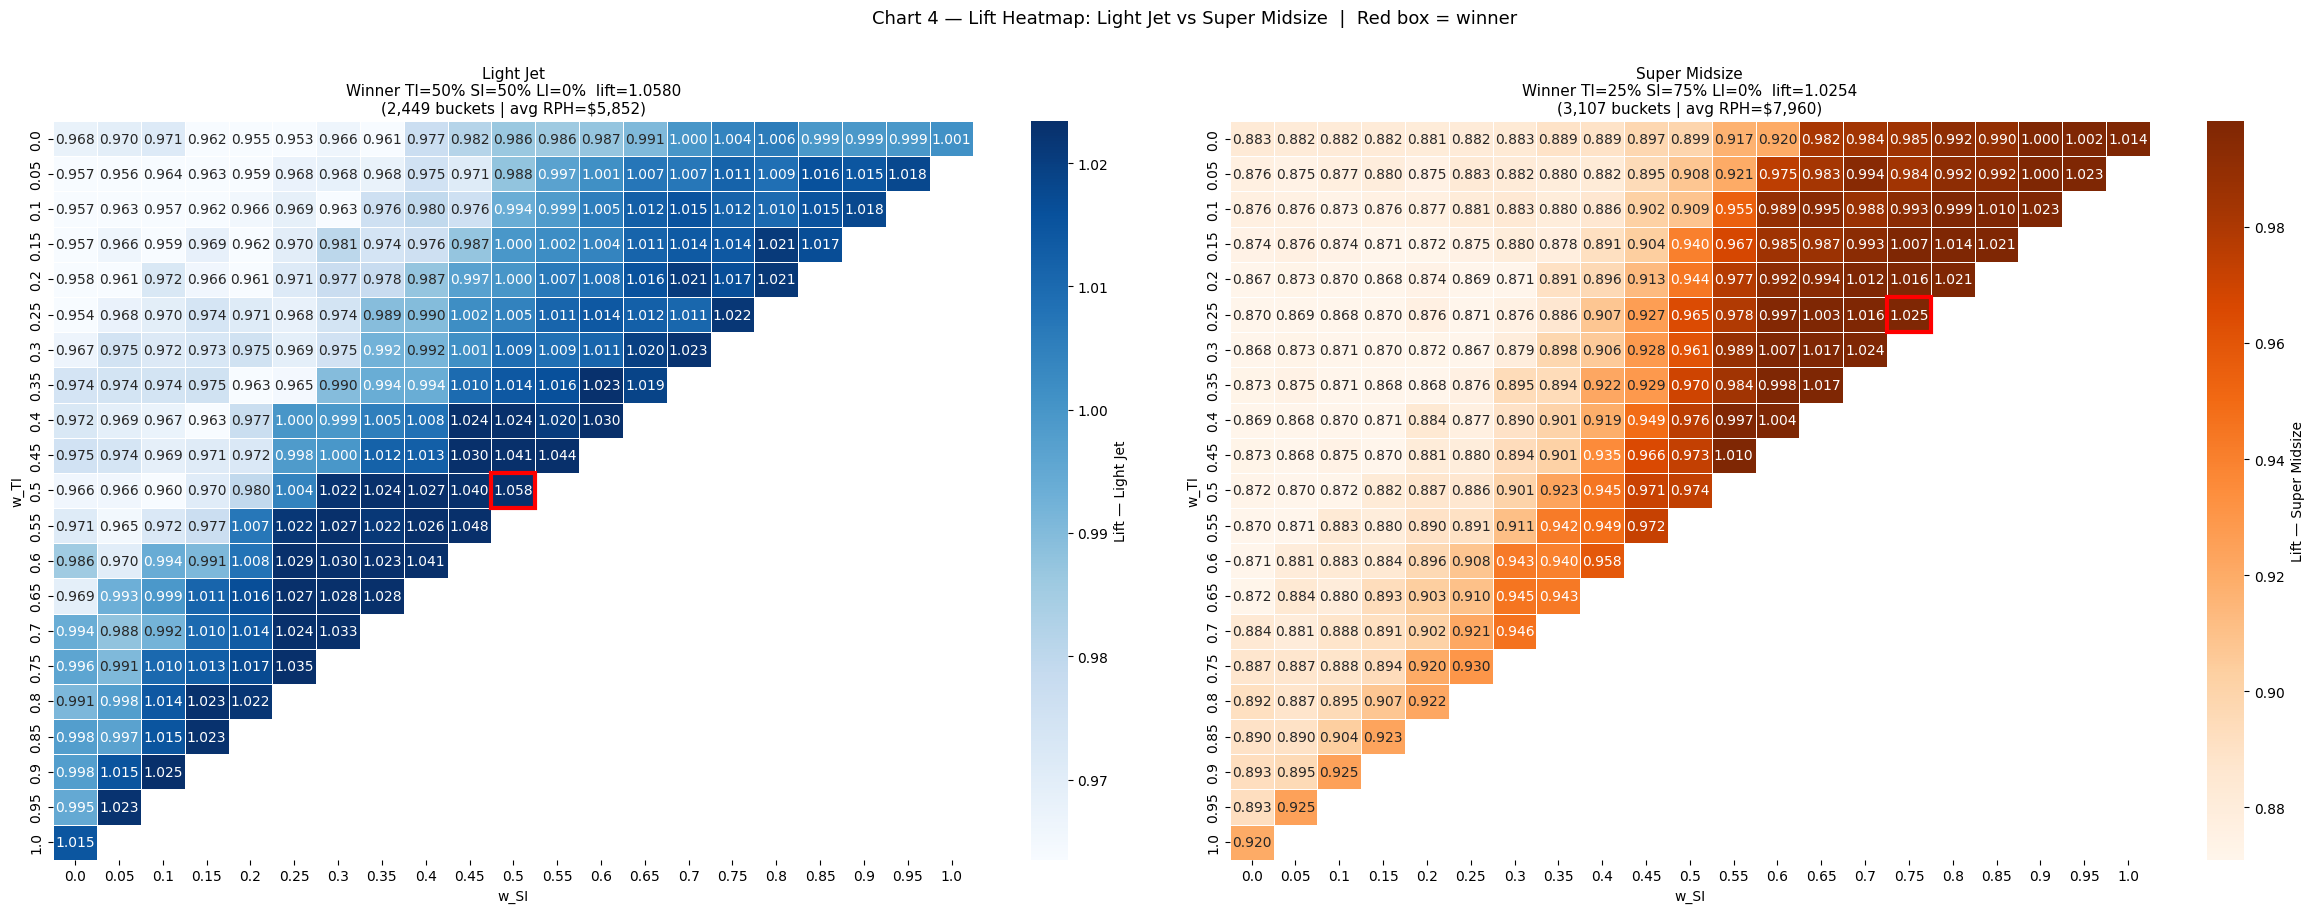

Saved: lj_vs_sm_heatmap.png


In [28]:
# Chart 4 — side-by-side lift heatmaps
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
for ax, (label, sr, cmap) in zip(axes, [
        ('Light Jet',     lj_result, 'Blues'),
        ('Super Midsize', sm_result, 'Oranges')]):
    res = sr['results']; w = sr['winner']
    piv = res.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')
    sns.heatmap(piv, annot=True, fmt='.3f', cmap=cmap,
                linewidths=0.4, ax=ax,
                vmin=res.lift.quantile(0.10), vmax=res.lift.quantile(0.90),
                cbar_kws={'label':f'Lift — {label}'})
    w_ti_v = list(piv.index); w_si_v = list(piv.columns)
    try:
        ri = min(range(len(w_ti_v)), key=lambda i: abs(w_ti_v[i]-w.w_TI))
        ci = min(range(len(w_si_v)), key=lambda i: abs(w_si_v[i]-w.w_SI))
        ax.add_patch(plt.Rectangle((ci,ri),1,1,fill=False,edgecolor='red',lw=3))
    except: pass
    ax.set_title(f'{label}\n'
                 f'Winner TI={w.w_TI:.0%} SI={w.w_SI:.0%} LI={w.w_LI:.0%}  lift={w.lift:.4f}\n'
                 f'({sr["n_buckets"]:,} buckets | avg RPH=${sr["benchmark_rph"]:,.0f})',
                 fontsize=11)
    ax.set_xlabel('w_SI'); ax.set_ylabel('w_TI')
plt.suptitle('Chart 4 — Lift Heatmap: Light Jet vs Super Midsize  |  Red box = winner',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lj_vs_sm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lj_vs_sm_heatmap.png')


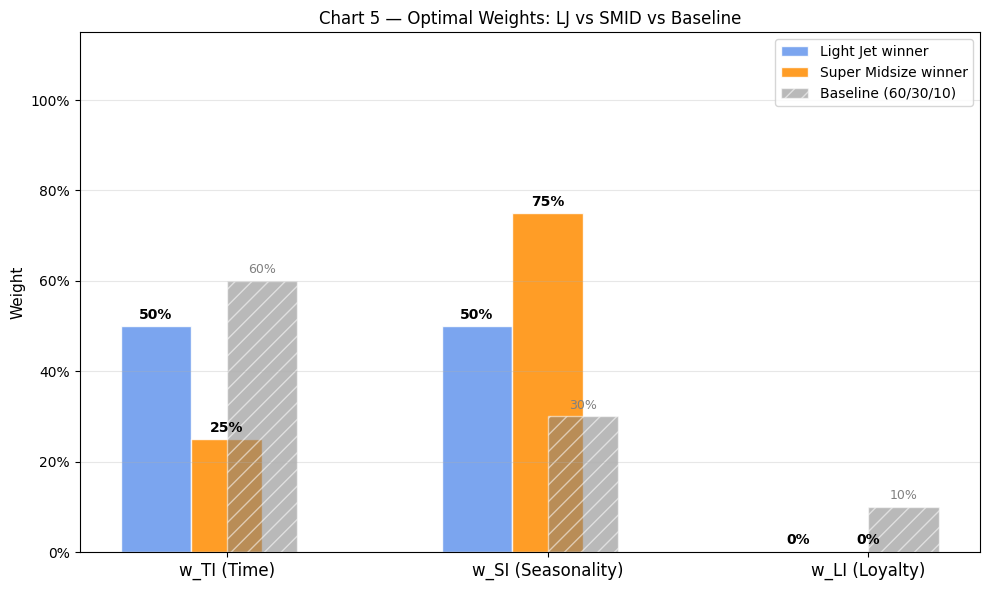

Saved: lj_vs_sm_weights.png


In [29]:
# Chart 5 — winner weight bar comparison
labels = ['w_TI (Time)', 'w_SI (Seasonality)', 'w_LI (Loyalty)']
x = np.arange(3); width = 0.22
fig, ax = plt.subplots(figsize=(10,6))
for i, (label, sr, color) in enumerate([
        ('Light Jet',     lj_result, 'cornflowerblue'),
        ('Super Midsize', sm_result, 'darkorange')]):
    w = sr['winner']
    vals = [w.w_TI, w.w_SI, w.w_LI]
    bars = ax.bar(x+(i-0.5)*width, vals, width, label=f'{label} winner',
                  color=color, alpha=0.85, edgecolor='white')
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{v:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
base_bars = ax.bar(x+width, list(BASELINE_W), width,
                   label='Baseline (60/30/10)', color='grey', alpha=0.55,
                   edgecolor='white', hatch='//')
for b,v in zip(base_bars,BASELINE_W):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{v:.0%}', ha='center', va='bottom', fontsize=9, color='grey')
ax.set_xticks(x+width*0.5); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Weight', fontsize=11); ax.set_ylim(0,1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_title('Chart 5 — Optimal Weights: LJ vs SMID vs Baseline', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lj_vs_sm_weights.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lj_vs_sm_weights.png')


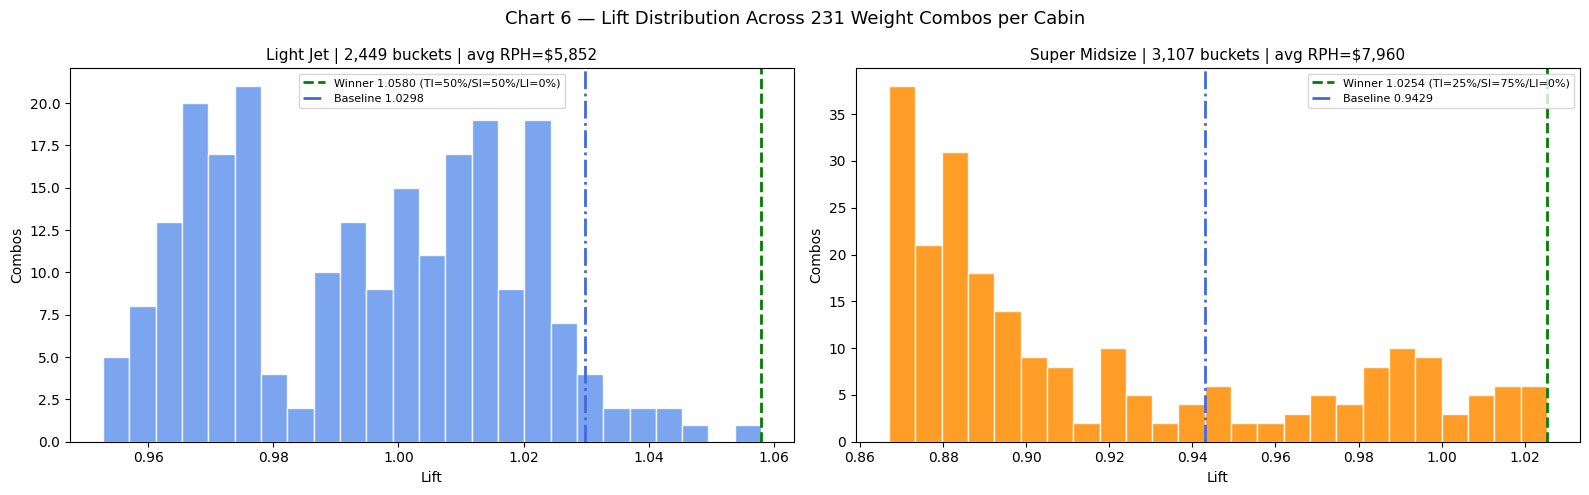

Saved: lj_vs_sm_dist.png


In [30]:
# Chart 6 — lift distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(16,5))
for ax, (label, sr, color) in zip(axes, [
        ('Light Jet',     lj_result, 'cornflowerblue'),
        ('Super Midsize', sm_result, 'darkorange')]):
    res = sr['results']; w = sr['winner']; bl = sr['baseline']
    ax.hist(res.lift, bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(w.lift, color='green', ls='--', lw=2,
               label=f'Winner {w.lift:.4f} (TI={w.w_TI:.0%}/SI={w.w_SI:.0%}/LI={w.w_LI:.0%})')
    if bl is not None:
        ax.axvline(bl.lift, color='royalblue', ls='-.', lw=2, label=f'Baseline {bl.lift:.4f}')
    ax.set_title(f'{label} | {sr["n_buckets"]:,} buckets | avg RPH=${sr["benchmark_rph"]:,.0f}', fontsize=11)
    ax.set_xlabel('Lift'); ax.set_ylabel('Combos'); ax.legend(fontsize=8)
plt.suptitle('Chart 6 — Lift Distribution Across 231 Weight Combos per Cabin', fontsize=13)
plt.tight_layout()
plt.savefig('lj_vs_sm_dist.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: lj_vs_sm_dist.png')


---
# Part 4 — Month-by-Month Analysis

The grid search is run **separately for each calendar month** using only that month's buckets.  
Benchmark for each month = that month's average RPH.

This reveals seasonal patterns:
- Do summer months (Jul/Aug) weight SI more heavily?
- Do winter months shift toward TI (time-sensitive, last-minute bookings)?
- Which month has the highest lift potential?

| Column | Meaning |
|--------|---------|
| `Optimal w_TI / w_SI / w_LI` | Best weights for that month |
| `Winner Lift` | Top-decile RPH / that month's avg RPH |
| `Improvement` | % gain over baseline (60/30/10) within that month |


In [31]:
months = sorted(buckets['month'].dropna().unique())
print(f'Months in data: {months}')
print()

month_results = {}
for mo in months:
    mo_bkts = buckets[buckets['month'] == mo].copy()
    if len(mo_bkts) < 10:
        print(f'Month {mo}: only {len(mo_bkts)} buckets — skipping')
        continue
    mo_avg_rph = mo_bkts['total_final_revenue'].sum() / mo_bkts['total_hours'].sum()
    mo_hours   = mo_bkts['total_hours'].sum()
    result = run_grid_search(
        mo_bkts, f'Month {int(mo)}',
        benchmark_rph=mo_avg_rph, benchmark_hours=mo_hours,
        W=W, SPEARMAN_THRESHOLD=SPEARMAN_THRESHOLD,
        TOP_DECILE_HOURS_PCT=TOP_DECILE_HOURS_PCT,
    )
    month_results[int(mo)] = result


Months in data: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

[Month 1]  159 ms  |  lift 0.8863–1.0185  |  Spearman -0.063–0.039  |  stable: 0/231
  Winner: TI=50%  SI=50%  LI=0%  lift=1.0185  (WINNER (Fallback ≥ 0.001))
  Baseline (60/30/10): lift=0.9427  rank=#89  improvement=+8.04%
[Month 2]  157 ms  |  lift 0.9413–1.1550  |  Spearman -0.155–0.108  |  stable: 0/231
  Winner: TI=10%  SI=70%  LI=20%  lift=1.1550  (WINNER (Fallback ≥ 0.047))
  Baseline (60/30/10): lift=1.0413  rank=#103  improvement=+10.93%
[Month 3]  154 ms  |  lift 0.9512–1.0653  |  Spearman -0.112–0.146  |  stable: 0/231
  Winner: TI=20%  SI=80%  LI=0%  lift=1.0653  (WINNER (Fallback ≥ 0.058))
  Baseline (60/30/10): lift=1.0036  rank=#119  improvement=+6.14%
[Month 4]  152 ms  |  lift 0.9181–1.0262  |  Spearman -0.078–0.069  |  stable: 0/231
  Winner: TI=35%  SI=50%  LI=15%  lift=1.0262  (WINNER (Fallba

### Month Summary Table
Each row = one month. Shows optimal weights, lift, top-decile RPH, and improvement vs baseline.


In [32]:
MONTH_NAMES = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

mo_rows = []
for mo, sr in sorted(month_results.items()):
    w  = sr['winner']; bl = sr['baseline']
    bm = sr['bm_mask']; res = sr['results']
    bl_lift = bl.lift if bl is not None else None
    bl_rank = res[bm].index[0]+1 if bl is not None else None
    mo_rows.append({
        'Month'           : f"{mo} — {MONTH_NAMES.get(mo,mo)}",
        'Buckets'         : sr['n_buckets'],
        'Flights'         : sr['n_flights'],
        'Avg RPH'         : f"${sr['benchmark_rph']:,.0f}",
        'w_TI'            : f"{w.w_TI:.0%}",
        'w_SI'            : f"{w.w_SI:.0%}",
        'w_LI'            : f"{w.w_LI:.0%}",
        'Winner Lift'     : f"{w.lift:.4f}",
        'Top-dec RPH'     : f"${w.top_decile_rph:,.0f}",
        'Spearman'        : f"{w.spearman:.3f}",
        'Stable Combos'   : sr['n_stable'],
        'Baseline Lift'   : f"{bl_lift:.4f}" if bl_lift else 'n/a',
        'BL Rank'         : f"#{bl_rank}" if bl_rank else 'n/a',
        'Improvement'     : f"+{(w.lift-bl_lift)/bl_lift*100:.2f}%" if bl_lift else 'n/a',
    })

mo_summary = pd.DataFrame(mo_rows).set_index('Month')
display(mo_summary)


,Buckets,Flights,Avg RPH,w_TI,w_SI,w_LI,Winner Lift,Top-dec RPH,Spearman,Stable Combos,Baseline Lift,BL Rank,Improvement
Month,,,,,,,,,,,,,
1 — Jan,616,4232,"$7,295",50%,50%,0%,1.0185,"$7,430",0.038,0,0.9427,#89,+8.04%
2 — Feb,532,3562,"$7,494",10%,70%,20%,1.1550,"$8,656",0.053,0,1.0413,#103,+10.93%
3 — Mar,650,4432,"$7,535",20%,80%,0%,1.0653,"$8,027",0.127,0,1.0036,#119,+6.14%
4 — Apr,564,3658,"$7,496",35%,50%,15%,1.0262,"$7,693",0.022,0,0.9705,#110,+5.74%
5 — May,570,3631,"$6,998",25%,55%,20%,1.0480,"$7,334",0.033,0,1.0330,#4,+1.45%
6 — Jun,630,4138,"$6,882",35%,65%,0%,1.0062,"$6,925",0.037,0,0.9600,#109,+4.81%
7 — Jul,675,4436,"$6,786",20%,75%,5%,1.0658,"$7,233",0.185,0,1.0345,#36,+3.03%
8 — Aug,571,3724,"$7,049",0%,100%,0%,1.1269,"$7,943",0.189,0,1.0240,#90,+10.05%
9 — Sep,555,3667,"$6,940",45%,50%,5%,1.0192,"$7,073",0.002,0,0.9797,#76,+4.03%


### Chart 7 — Optimal Weights by Month (Heatmap)
Each row = one month, each column = one weight signal.  
Colour shows the optimal weight value — reveals how the mix shifts across the calendar year.


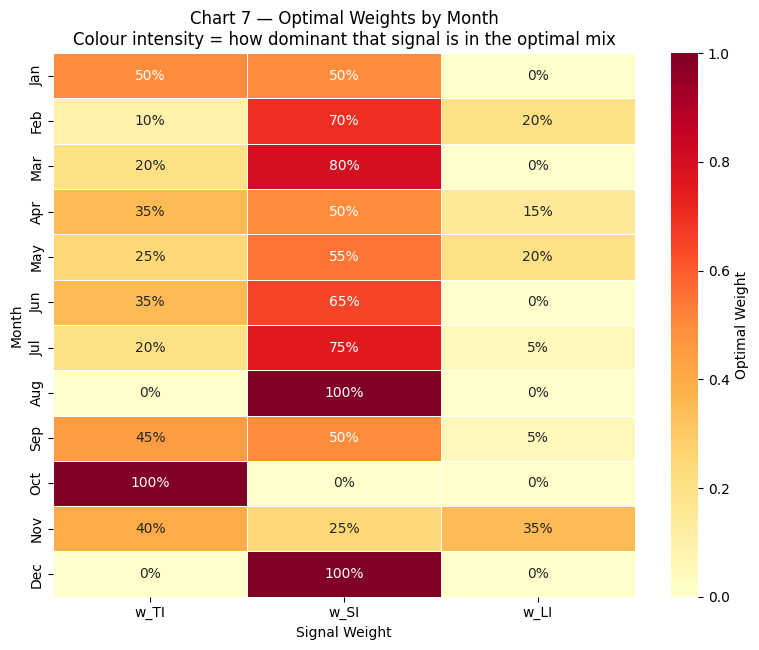

Saved: month_weights_heatmap.png


In [33]:
# Chart 7 — weight heatmap by month
mo_weight_data = []
for mo, sr in sorted(month_results.items()):
    w = sr['winner']
    mo_weight_data.append({'Month': f"{MONTH_NAMES.get(mo,mo)}",
                           'w_TI': w.w_TI, 'w_SI': w.w_SI, 'w_LI': w.w_LI})
mo_w_df = pd.DataFrame(mo_weight_data).set_index('Month')

fig, ax = plt.subplots(figsize=(8, max(6, len(mo_w_df)*0.55)))
sns.heatmap(mo_w_df, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label':'Optimal Weight'})
ax.set_title('Chart 7 — Optimal Weights by Month\n'
             'Colour intensity = how dominant that signal is in the optimal mix', fontsize=12)
ax.set_xlabel('Signal Weight'); ax.set_ylabel('Month')
plt.tight_layout()
plt.savefig('month_weights_heatmap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: month_weights_heatmap.png')


### Chart 8 — Winner Lift by Month
Which months have the highest potential gain from optimised weights?


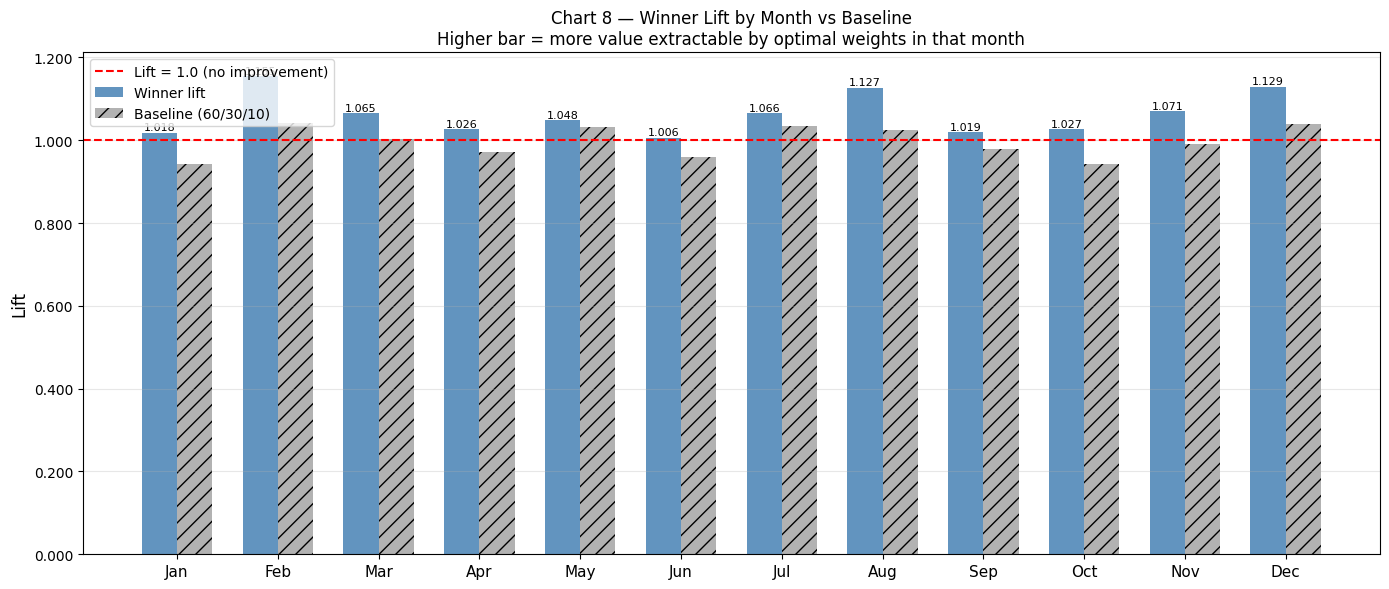

Saved: month_lift_bars.png


In [34]:
# Chart 8 — lift by month bar chart
mo_labels = [f"{MONTH_NAMES.get(mo,mo)}" for mo in sorted(month_results.keys())]
mo_lifts  = [month_results[mo]['winner'].lift for mo in sorted(month_results.keys())]
mo_bl     = [month_results[mo]['baseline'].lift if month_results[mo]['baseline'] is not None else 0
              for mo in sorted(month_results.keys())]

x = np.arange(len(mo_labels)); width = 0.35
fig, ax = plt.subplots(figsize=(14,6))
bars1 = ax.bar(x - width/2, mo_lifts, width, label='Winner lift', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, mo_bl,    width, label='Baseline (60/30/10)', color='grey', alpha=0.6, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(mo_labels, fontsize=11)
ax.axhline(1.0, color='red', ls='--', lw=1.5, label='Lift = 1.0 (no improvement)')
ax.set_ylabel('Lift', fontsize=12)
ax.set_title('Chart 8 — Winner Lift by Month vs Baseline\n'
             'Higher bar = more value extractable by optimal weights in that month', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.3f}'))
for b,v in zip(bars1, mo_lifts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.0005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('month_lift_bars.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: month_lift_bars.png')


---
## Export & Final Summary

Exports the full-network 231-combo results to CSV.  
Prints a board-ready summary across all analyses.


In [35]:
out = net_result['results'][['w_TI','w_SI','w_LI','lift','spearman','top_decile_rph','verdict']].copy()
out.insert(0,'rank', range(1,len(out)+1))
out.to_csv(RESULTS_PATH, index=False)
print(f'Exported {len(out)} rows → {RESULTS_PATH}')


Exported 231 rows → optimization_results.csv


In [36]:
print('='*72)
print(' WEIGHT OPTIMISATION RESULTS SUMMARY')
print('='*72)
print(f'  Network avg RPH (benchmark): ${NETWORK_AVG_RPH:,.0f}')
print(f'  Total billed hours          : {NETWORK_TOTAL_HOURS:,.0f}')
print(f'  Revenue formula             : final_rev = (flightcost-ToggleDelta)×0.8 + ToggleDelta')
print(f'  Network RPH formula         : sum(flightcost×0.8) / sum(hours)')
print()
print('── FULL NETWORK ──────────────────────────────────────────────────────')
w_n = net_result['winner']; bl_n = net_result['baseline']
print(f'  Winner  TI={w_n.w_TI:.0%} SI={w_n.w_SI:.0%} LI={w_n.w_LI:.0%}  '
      f'lift={w_n.lift:.4f}  top-RPH=${w_n.top_decile_rph:,.0f}')
if bl_n is not None:
    print(f'  Baseline lift={bl_n.lift:.4f}  '
          f'improvement=+{(w_n.lift-bl_n.lift)/bl_n.lift*100:.2f}%')
print()
print('── LIGHT JET ─────────────────────────────────────────────────────────')
print(f'  Avg RPH: ${lj_avg_rph:,.0f}')
print(f'  Winner  TI={w_lj.w_TI:.0%} SI={w_lj.w_SI:.0%} LI={w_lj.w_LI:.0%}  '
      f'lift={w_lj.lift:.4f}  top-RPH=${w_lj.top_decile_rph:,.0f}')
if bl_lj is not None:
    print(f'  Baseline lift={bl_lj.lift:.4f}  '
          f'improvement=+{(w_lj.lift-bl_lj.lift)/bl_lj.lift*100:.2f}%')
print()
print('── SUPER MIDSIZE ─────────────────────────────────────────────────────')
print(f'  Avg RPH: ${sm_avg_rph:,.0f}')
print(f'  Winner  TI={w_sm.w_TI:.0%} SI={w_sm.w_SI:.0%} LI={w_sm.w_LI:.0%}  '
      f'lift={w_sm.lift:.4f}  top-RPH=${w_sm.top_decile_rph:,.0f}')
if bl_sm is not None:
    print(f'  Baseline lift={bl_sm.lift:.4f}  '
          f'improvement=+{(w_sm.lift-bl_sm.lift)/bl_sm.lift*100:.2f}%')
print()
print('── BY MONTH ──────────────────────────────────────────────────────────')
for mo, sr in sorted(month_results.items()):
    w = sr['winner']; bl = sr['baseline']
    impr = f"+{(w.lift-bl.lift)/bl.lift*100:.2f}%" if bl is not None else 'n/a'
    print(f'  {MONTH_NAMES.get(mo,mo):>3}: TI={w.w_TI:.0%} SI={w.w_SI:.0%} LI={w.w_LI:.0%}  '
          f'lift={w.lift:.4f}  vs baseline={impr}')
print()
print('── OUTPUTS ───────────────────────────────────────────────────────────')
for f in ['optimization_results.csv',
           'net_heatmaps.png','net_scatter.png','net_top_units.png',
           'lj_heatmaps.png','lj_scatter.png','lj_top_units.png',
           'sm_heatmaps.png','sm_scatter.png','sm_top_units.png',
           'lj_vs_sm_heatmap.png','lj_vs_sm_weights.png','lj_vs_sm_dist.png',
           'month_weights_heatmap.png','month_lift_bars.png']:
    print(f'  {f}')
print('='*72)


 WEIGHT OPTIMISATION RESULTS SUMMARY
  Network avg RPH (benchmark): $6,976
  Total billed hours          : 227,023
  Revenue formula             : final_rev = (flightcost-ToggleDelta)×0.8 + ToggleDelta
  Network RPH formula         : sum(flightcost×0.8) / sum(hours)

── FULL NETWORK ──────────────────────────────────────────────────────
  Winner  TI=45% SI=55% LI=0%  lift=1.0711  top-RPH=$7,472
  Baseline lift=1.0565  improvement=+1.38%

── LIGHT JET ─────────────────────────────────────────────────────────
  Avg RPH: $5,852
  Winner  TI=50% SI=50% LI=0%  lift=1.0580  top-RPH=$6,192
  Baseline lift=1.0298  improvement=+2.74%

── SUPER MIDSIZE ─────────────────────────────────────────────────────
  Avg RPH: $7,960
  Winner  TI=25% SI=75% LI=0%  lift=1.0254  top-RPH=$8,162
  Baseline lift=0.9429  improvement=+8.74%

── BY MONTH ──────────────────────────────────────────────────────────
  Jan: TI=50% SI=50% LI=0%  lift=1.0185  vs baseline=+8.04%
  Feb: TI=10% SI=70% LI=20%  lift=1.1550  v